# Algorithmic VWAP Sigma Engine

Clean research notebook for the VWAP sigma-band strategy.

This notebook is used to:
- calculate VWAP and sigma probability bands
- detect continuation and mean-reversion setups
- route/filter raw signals
- simulate trades
- compare strategy results
- audit skipped opportunities
- prepare the final logic for a future live MT5 runner

This is not the live runner yet.

## Table of Contents

1. Imports and paths
2. Strategy control panel
3. Dataset configuration
4. VWAP and sigma band engine
5. Continuation signal engine
6. Mean-reversion signal engine
7. Router and strategy filter
8. Trade simulation and risk engine
9. Experiment runner
10. Quick results
11. Core charts
12. Risk diagnostics
13. Audits and detailed diagnostics
14. Experiment logging
15. Future live runner notes

## Imports and paths

This section contains the notebook imports, project-root detection, and output paths.

In [127]:
from pathlib import Path
from pprint import pprint
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


def find_project_root(start_path: Path | None = None) -> Path:
    """
    Find the project root by walking upward until the expected repository
    structure is found.

    This works whether the project was cloned with Git or downloaded as a ZIP,
    and whether the notebook is run from the project root or from notebooks/.
    """
    if start_path is None:
        start_path = Path.cwd()

    start_path = start_path.resolve()

    for path in [start_path, *start_path.parents]:
        has_project_structure = (
            (path / "src").is_dir()
            and (path / "data").is_dir()
            and (path / "notebooks").is_dir()
        )

        has_repo_marker = (
            (path / ".git").exists()
            or (path / "README.md").exists()
            or (path / "requirements.txt").exists()
        )

        if has_project_structure and has_repo_marker:
            return path

    raise FileNotFoundError(
        "Could not find the project root. Make sure this notebook is being run "
        "from inside the VWAP-probability-band-engine project folder."
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
HISTORICAL_DATA_DIR = DATA_DIR / "historical"
SRC_DIR = PROJECT_ROOT / "src"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
OUTPUT_DIR = ARTIFACTS_DIR / "algorithmic_vwap_sigma_engine"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Current working directory:", Path.cwd())
print("Detected project root:", PROJECT_ROOT)
print("Historical data folder:", HISTORICAL_DATA_DIR)
print("Source folder:", SRC_DIR)
print("Output folder:", OUTPUT_DIR)

Current working directory: c:\GitHub Projects\VWAP-probability-band-engine\notebooks
Detected project root: C:\GitHub Projects\VWAP-probability-band-engine
Historical data folder: C:\GitHub Projects\VWAP-probability-band-engine\data\historical
Source folder: C:\GitHub Projects\VWAP-probability-band-engine\src
Output folder: C:\GitHub Projects\VWAP-probability-band-engine\artifacts\algorithmic_vwap_sigma_engine


## Strategy control panel

This section controls the strategy behaviour from one place.

The control panel is separated by role:
- strategy family switches
- continuation entry-type switches
- router and strategy-filter controls
- setup-specific quality filters
- future router-blocked override controls
- execution and risk controls
- reporting and audit controls

The goal is to make it clear which stage each setting affects.

In [128]:
# ============================================================
# 1. MAIN STRATEGY SWITCHES
# ============================================================
# Purpose:
#   Turn major strategy families on or off.
#
# Scope:
#   These are top-level switches. If a family is disabled here,
#   that family should not create trades.
#
# Default:
#   Continuation is enabled. Mean reversion and add-ons are disabled
#   until proven stable.
#
# Risk:
#   Enabling extra strategy families can change trade frequency,
#   drawdown, and attribution.

ENABLE_CONTINUATION = True
ENABLE_MEAN_REVERSION = False
ENABLE_PROTECTED_ADDONS = False


# ============================================================
# 2. CONTINUATION ENTRY TYPES
# ============================================================
# Purpose:
#   Control which continuation setup families can create raw signals.
#
# Scope:
#   These switches affect raw continuation setup creation only.
#
# Default:
#   The current primary continuation profile keeps the main continuation
#   families available.
#
# Risk:
#   Disabling a setup family can hide valid opportunity types.
#   Enabling too many weak setup families without filtering can increase noise.

ENABLE_S_TIER = True
ENABLE_DYNAMIC_S_TIER = True
ENABLE_A_TIER = True
ENABLE_DELAYED_PULLBACK = True


# ============================================================
# 3. ROUTER / STRATEGY FILTER
# ============================================================
# Purpose:
#   Decide whether raw setups fit the current market regime.
#
# Scope:
#   This is a permission layer after raw signal creation.
#   It should not be confused with raw setup detection.
#
# Default:
#   Enabled because it blocks many weak-regime signals.
#
# Risk:
#   Turning this off can allow many low-quality trades.
#   Leaving it too strict may block valid A-tier continuation opportunities.

USE_STRATEGY_FILTER = True
STRATEGY_FILTER_MODE = "v4_dynamic_regime_selector"


# ============================================================
# 4. STRATEGY FILTER OVERRIDES
# ============================================================
# Purpose:
#   Future research controls for router-blocked setups.
#
# Scope:
#   These should only apply after the router blocks a raw setup.
#   They should not affect router-approved trades.
#
# Default:
#   OFF. They should not change current results.
#
# Risk:
#   If implemented carelessly, these can become the same as removing
#   the strategy filter. They must require extra quality confirmation.

ALLOW_BLOCKED_S_TIER_WITH_EXTRA_QUALITY = False
ALLOW_BLOCKED_DYNAMIC_S_TIER_WITH_EXTRA_QUALITY = False
ALLOW_BLOCKED_A_TIER_WITH_EXTRA_QUALITY = False
ALLOW_BLOCKED_DELAYED_PULLBACK_WITH_EXTRA_QUALITY = False


# ============================================================
# 5. SETUP-SPECIFIC QUALITY FILTERS
# ============================================================
# Purpose:
#   Extra quality checks after a raw setup exists.
#
# Scope:
#   These should clearly state whether they apply globally,
#   only to S-tier, only to A-tier, only to delayed pullbacks,
#   only to mean reversion, or only to future router-blocked overrides.
#
# Default:
#   Preserve the current primary continuation profile.
#
# Risk:
#   Turning on too many filters at once may double-filter trades
#   that the strategy router already approved.

USE_S_TIER_CLEAN_STATE_FILTER = True

USE_RED_SHIFT_FLOOR = False
USE_TREND_HEALTH_FILTER = True
USE_CANDLE_QUALITY_FILTER = True
USE_EXTENSION_FILTER = True


# ============================================================
# 6. RISK AND RUNNER MANAGEMENT
# ============================================================
# Purpose:
#   Define continuation trade risk, target, breakeven, and runner behaviour.
#
# Scope:
#   Applies to continuation trades unless a setup-specific exit model overrides it.
#
# Default:
#   Uses the current primary continuation runner profile.
#
# Risk:
#   Changing stop size, target, breakeven, or runner locks can materially
#   change all headline results.

SL_POINTS = 36.0
ORIGINAL_TP_POINTS = 72.0
BE_TRIGGER_POINTS = 36.0

RUNNER_MODE = "always"
RUNNER_TARGET_R = 7.0
USE_LEGACY_EARLY_RUNNER_LOCK = False

RUNNER_TRAIL_RULES_R = [
    {"trigger_r": 1.0, "lock_r": 0.0, "label": "BE"},
    {"trigger_r": 2.7, "lock_r": 2.0, "label": "TRAIL_LOCK_2R"},
    {"trigger_r": 3.7, "lock_r": 3.0, "label": "TRAIL_LOCK_3R"},
    {"trigger_r": 4.7, "lock_r": 4.0, "label": "TRAIL_LOCK_4R"},
    {"trigger_r": 5.7, "lock_r": 5.0, "label": "TRAIL_LOCK_5R"},
    {"trigger_r": 6.7, "lock_r": 6.0, "label": "TRAIL_LOCK_6R"},
]


# ============================================================
# 7. PROTECTED CONTINUATION ADD-ONS
# ============================================================
# Purpose:
#   Allow another continuation trade only when an existing continuation
#   trade is already protected.
#
# Scope:
#   Applies to continuation stacking logic, not mean reversion.
#
# Default:
#   OFF until proven stable.
#
# Risk:
#   If configured badly, this can create multiple full-risk trades.
#   The intended rule is no second fresh full-risk trade.

ENABLE_PROTECTED_ADDONS = False
ADDON_REQUIRES_EXISTING_TRADE_PROTECTED = True
ADDON_REQUIRES_SAME_DIRECTION = True
MAX_OPEN_CONTINUATION_TRADES = 2


# ============================================================
# 8. MEAN-REVERSION SETTINGS
# ============================================================
# Purpose:
#   Configure the optional mean-reversion module.
#
# Scope:
#   Mean reversion is separate from continuation.
#   It targets VWAP and should not use the continuation runner.
#
# Default:
#   Disabled because early tests over-traded.
#
# Risk:
#   Mean reversion can add many trades and increase drawdown if not filtered.

ENABLE_MEAN_REVERSION = False

MR_TARGET_MODE = "vwap"
MR_STOP_MODE = "structure"
MR_MAX_SL_POINTS = 14.0
MR_MIN_TARGET_RR = 2.0

ENABLE_MR_GREEN_BE = True
MR_BE_TRIGGER_MODE = "inner_green"
MR_BE_REQUIRES_CLOSE_BEYOND_GREEN = True


# ============================================================
# 9. DAILY RISK / SESSION CONTROLS
# ============================================================
# Purpose:
#   Control account/risk/session-level trade permissions.
#
# Scope:
#   These controls operate after signal selection.
#
# Default:
#   Preserve current research profile.
#
# Risk:
#   Tight risk/session settings can reduce trade count.
#   Loose settings can increase drawdown exposure.

MAX_DAILY_LOSS_R = -2
DAILY_PROFIT_CAP_PCT = 999.0
MAX_CONSECUTIVE_SL = 2
NO_NEW_TRADES_AFTER = "19:00"
SESSION_FILTER_ENABLED = False


# ============================================================
# 10. AUDITS / REPORTS / LOGGING
# ============================================================
# Purpose:
#   Explain what the model saw, selected, executed, or skipped.
#
# Scope:
#   These should not change trading logic.
#
# Default:
#   Enabled because this notebook is a research/control notebook.
#
# Risk:
#   These should not affect results. If toggling a report changes trades,
#   something is wired incorrectly.

ENABLE_RAW_SIGNAL_AUDIT = True
ENABLE_STRATEGY_FILTER_BLOCK_AUDIT = True
ENABLE_TRADE_ATTRIBUTION_REPORT = True
ENABLE_RISK_DIAGNOSTICS = True
ENABLE_ACCOUNT_SURVIVAL_REPORT = True
ENABLE_EXPERIMENT_LOGGING = True

In [129]:
# ============================================================
# INTERNAL CONFIG MAPPING
# ============================================================
# Purpose:
#   Map the readable control-panel settings above into the internal keys
#   expected by the migrated engine code.
#
# Scope:
#   This cell is compatibility glue. Future edits should normally happen
#   in the readable control panel above, not by scattering overrides later.
#
# Default:
#   Keeps the current primary continuation profile active.
#
# Risk:
#   Changing internal keys here can alter strategy behaviour globally.

CONFIG = {
    # ------------------------------------------------------------------
    # Dataset
    # ------------------------------------------------------------------
    "csv_file": "US100_cash_M1_NY_session_1y.csv",
    "dataset_name": "US100_cash_M1_NY_session_1y",

    # ------------------------------------------------------------------
    # Strategy identity
    # ------------------------------------------------------------------
    "strategy_version": "algorithmic_vwap_sigma_engine",
    "strategy_description": "Clean modular VWAP sigma-band research engine",

    # ------------------------------------------------------------------
    # Session handling
    # ------------------------------------------------------------------
    "session_timezone": "Europe/London",
    "no_new_trades_after": NO_NEW_TRADES_AFTER,

    # ------------------------------------------------------------------
    # Direction controls
    # ------------------------------------------------------------------
    "allow_longs": True,
    "allow_shorts": True,

    # ------------------------------------------------------------------
    # Strategy family switches
    # ------------------------------------------------------------------
    "enable_continuation": ENABLE_CONTINUATION,
    "enable_v5_mr_orange_failure_entry": ENABLE_MEAN_REVERSION,
    "enable_protected_continuation_addons": ENABLE_PROTECTED_ADDONS,

    # ------------------------------------------------------------------
    # Continuation entry-type switches
    # ------------------------------------------------------------------
    "enable_v1_s_tier": ENABLE_S_TIER,
    "enable_dynamic_s_tier_touch_diagnostics": ENABLE_DYNAMIC_S_TIER,
    "enable_v3_a_tier_second_close": ENABLE_A_TIER,
    "enable_a_tier_delayed_pullback_entry": ENABLE_DELAYED_PULLBACK,

    # ------------------------------------------------------------------
    # Router / strategy-filter controls
    # ------------------------------------------------------------------
    "strategy_family": "continuation_only",
    "strategy_filter": STRATEGY_FILTER_MODE if USE_STRATEGY_FILTER else "off",
    "engine_mode": "intelligent" if USE_STRATEGY_FILTER else "manual",
    "enable_regime_router": USE_STRATEGY_FILTER,
    "regime_lookback_minutes": 20,

    # ------------------------------------------------------------------
    # Future router-blocked override controls
    # These are intentionally inactive placeholders for future research.
    # They should not affect current results until wired explicitly.
    # ------------------------------------------------------------------
    "allow_blocked_s_tier_with_extra_quality": ALLOW_BLOCKED_S_TIER_WITH_EXTRA_QUALITY,
    "allow_blocked_dynamic_s_tier_with_extra_quality": ALLOW_BLOCKED_DYNAMIC_S_TIER_WITH_EXTRA_QUALITY,
    "allow_blocked_a_tier_with_extra_quality": ALLOW_BLOCKED_A_TIER_WITH_EXTRA_QUALITY,
    "allow_blocked_delayed_pullback_with_extra_quality": ALLOW_BLOCKED_DELAYED_PULLBACK_WITH_EXTRA_QUALITY,

    # ------------------------------------------------------------------
    # Setup-specific quality filters
    # ------------------------------------------------------------------
    "enable_s_tier_clean_state_filter": USE_S_TIER_CLEAN_STATE_FILTER,

    "s_tier_use_entry_red_shift_floor": USE_RED_SHIFT_FLOOR,
    "a_tier_use_entry_red_shift_floor": USE_RED_SHIFT_FLOOR,

    "enable_v2_trend_health_filter": USE_TREND_HEALTH_FILTER,
    "enable_v2_continuation_health": USE_TREND_HEALTH_FILTER,
    "enable_v2_reclaim_recovery_health": USE_TREND_HEALTH_FILTER,

    "use_candle_quality_filter": USE_CANDLE_QUALITY_FILTER,
    "use_extension_filter": USE_EXTENSION_FILTER,

    # ------------------------------------------------------------------
    # Entry logic
    # ------------------------------------------------------------------
    "entry_timing": "next_bar_open",

    # ------------------------------------------------------------------
    # Fixed Nasdaq point trade levels
    # ------------------------------------------------------------------
    "sl_points": SL_POINTS,
    "tp_points": ORIGINAL_TP_POINTS,
    "be_trigger_points": BE_TRIGGER_POINTS,

    "normal_sl_points": SL_POINTS,
    "normal_tp_points": ORIGINAL_TP_POINTS,
    "normal_be_trigger_points": BE_TRIGGER_POINTS,

    # ------------------------------------------------------------------
    # Runner / exit manager controls
    # ------------------------------------------------------------------
    "enable_v5_exit_manager": True,
    "enable_runner_trailing": RUNNER_MODE != "off",
    "runner_mode": RUNNER_MODE,
    "runner_target_r": RUNNER_TARGET_R,
    "runner_trail_rules_r": RUNNER_TRAIL_RULES_R,

    "enable_be_plus_buffer": True,
    "be_plus_buffer_points": 3.0,

    "enable_legacy_early_runner_lock": USE_LEGACY_EARLY_RUNNER_LOCK,
    "legacy_early_runner_lock_only_when_tp_points_above": 60.0,
    "legacy_runner_reference_sl_points": 29.0,
    "legacy_runner_lock_trigger_r": 2.7,
    "legacy_runner_lock_r": 2.0,

    "runner_tp_points": SL_POINTS * RUNNER_TARGET_R,
    "trail_be_trigger_points": SL_POINTS * 1.0,
    "trail_lock_2r_trigger_points": SL_POINTS * 2.7,
    "trail_lock_3r_trigger_points": SL_POINTS * 3.7,
    "trail_lock_4r_trigger_points": SL_POINTS * 4.7,
    "trail_5r_tp_points": SL_POINTS * 5.0,

    "trail_lock_2r_points": SL_POINTS * 2.0,
    "trail_lock_3r_points": SL_POINTS * 3.0,
    "trail_lock_4r_points": SL_POINTS * 4.0,

    # ------------------------------------------------------------------
    # Protected continuation add-ons
    # ------------------------------------------------------------------
    "addon_requires_existing_trade_protected": ADDON_REQUIRES_EXISTING_TRADE_PROTECTED,
    "addon_requires_same_direction": ADDON_REQUIRES_SAME_DIRECTION,
    "max_open_continuation_trades": MAX_OPEN_CONTINUATION_TRADES,
    "allow_mr_addon_entries": False,
    "mr_one_trade_at_a_time": True,
    "addon_allowed_entry_families": [
        "S_TIER",
        "A_TIER",
        "DELAYED_PULLBACK",
    ],

    # ------------------------------------------------------------------
    # Mean-reversion module
    # ------------------------------------------------------------------
    "mr_target_mode": MR_TARGET_MODE,
    "mr_sl_mode": MR_STOP_MODE,
    "mr_max_sl_points": MR_MAX_SL_POINTS,
    "mr_min_target_rr": MR_MIN_TARGET_RR,

    "enable_mr_green_be": ENABLE_MR_GREEN_BE,
    "mr_be_trigger_mode": MR_BE_TRIGGER_MODE,
    "mr_be_requires_close_beyond_green": MR_BE_REQUIRES_CLOSE_BEYOND_GREEN,

    "mr_orange_confirm_closes": 2,
    "mr_orange_touch_lookback_bars": 3,
    "mr_use_locked_orange_touch": True,
    "mr_block_if_strong_continuation": True,
    "mr_require_weak_or_compressing_trend": True,
    "mr_max_entry_extension_from_orange_points": 10.0,
    "mr_first_trigger_only": True,
    "mr_cooldown_bars": 10,
    "mr_sl_cooldown_bars": 20,
    "mr_min_orange_to_vwap_distance_points": 12.0,
    "mr_require_stable_or_contracting_bands": True,
    "mr_block_if_orange_band_expanding_fast": True,
    "mr_expansion_lookback_bars": 3,
    "mr_max_orange_width_expansion_points": 8.0,
    "mr_stable_band_tolerance_points": 2.0,
    "mr_entry_priority": "after_continuation",

    # ------------------------------------------------------------------
    # Risk controls
    # ------------------------------------------------------------------
    "risk_per_trade_pct": 1.0,
    "max_daily_loss_r": MAX_DAILY_LOSS_R,
    "daily_max_consecutive_losses": MAX_CONSECUTIVE_SL,
    "daily_profit_cap_pct": DAILY_PROFIT_CAP_PCT,
    "max_consecutive_sl": MAX_CONSECUTIVE_SL,
    "max_no_tp_run_r": -6,

    # ------------------------------------------------------------------
    # Session controls
    # ------------------------------------------------------------------
    "enable_session_filter": SESSION_FILTER_ENABLED,
    "enabled_sessions": ["asia", "london", "new_york"],
    "session_windows": {
        "asia": ("00:00", "07:00"),
        "london": ("07:00", "13:30"),
        "new_york": ("13:30", "21:00"),
    },
    "allow_out_of_session_trades": False,

    # ------------------------------------------------------------------
    # Candle quality filters
    # ------------------------------------------------------------------
    "min_body_ratio": 0.25,
    "min_close_through_green": 1.0,
    "max_extension_from_green": 8.0,

    # ------------------------------------------------------------------
    # Feature lookbacks
    # ------------------------------------------------------------------
    "shift_lookback": 3,
    "acceptance_lookback": 3,
    "trend_lane_lookback": 5,
    "trend_damage_lookback": 5,
    "compression_lookback": 5,
    "flat_vwap_lookback": 5,
    "vwap_cross_lookback": 8,

    # ------------------------------------------------------------------
    # Reporting / audits / exports
    # ------------------------------------------------------------------
    "enable_v5_raw_signal_audit": ENABLE_RAW_SIGNAL_AUDIT,
    "enable_strategy_filter_block_audit": ENABLE_STRATEGY_FILTER_BLOCK_AUDIT,
    "enable_trade_attribution_report": ENABLE_TRADE_ATTRIBUTION_REPORT,
    "enable_risk_diagnostics": ENABLE_RISK_DIAGNOSTICS,
    "enable_account_survival_report": ENABLE_ACCOUNT_SURVIVAL_REPORT,
    "enable_experiment_logging": ENABLE_EXPERIMENT_LOGGING,

    "save_trade_log": True,
    "save_daily_summary": True,
    "save_skipped_signals": True,
    "save_config_snapshot": True,
    "raw_signal_audit_max_rows": 300,
    "raw_signal_audit_save_csv": True,
    "strategy_filter_block_audit_save_csv": True,
    "strategy_filter_block_audit_max_rows": 300,
}

print("Strategy control panel mapped into internal CONFIG:")
pprint(CONFIG)

Strategy control panel mapped into internal CONFIG:
{'a_tier_use_entry_red_shift_floor': False,
 'acceptance_lookback': 3,
 'addon_allowed_entry_families': ['S_TIER', 'A_TIER', 'DELAYED_PULLBACK'],
 'addon_requires_existing_trade_protected': True,
 'addon_requires_same_direction': True,
 'allow_blocked_a_tier_with_extra_quality': False,
 'allow_blocked_delayed_pullback_with_extra_quality': False,
 'allow_blocked_dynamic_s_tier_with_extra_quality': False,
 'allow_blocked_s_tier_with_extra_quality': False,
 'allow_longs': True,
 'allow_mr_addon_entries': False,
 'allow_out_of_session_trades': False,
 'allow_shorts': True,
 'be_plus_buffer_points': 3.0,
 'be_trigger_points': 36.0,
 'compression_lookback': 5,
 'csv_file': 'US100_cash_M1_NY_session_1y.csv',
 'daily_max_consecutive_losses': 2,
 'daily_profit_cap_pct': 999.0,
 'dataset_name': 'US100_cash_M1_NY_session_1y',
 'enable_a_tier_delayed_pullback_entry': True,
 'enable_account_survival_report': True,
 'enable_be_plus_buffer': True,
 

## Dataset configuration

This section defines dataset paths and dataset metadata only.

No strategy logic belongs in this section.

In [130]:
DATASETS = [
    {
        "label": "30d",
        "csv_file": "US100_cash_M1_NY_session_30d.csv",
        "dataset_name": "US100_cash_M1_NY_session_30d",
    },
    {
        "label": "1Y",
        "csv_file": "US100_cash_M1_NY_session_1y.csv",
        "dataset_name": "US100_cash_M1_NY_session_1y",
    },
    {
        "label": "2021 partial",
        "csv_file": "US100_cash_M1_NY_session_calm_2021_partial.csv",
        "dataset_name": "US100_cash_M1_NY_session_calm_2021_partial",
    },
    {
        "label": "2022 volatile",
        "csv_file": "US100_cash_M1_NY_session_volatile_2022.csv",
        "dataset_name": "US100_cash_M1_NY_session_volatile_2022",
    },
    {
        "label": "War 22/23",
        "csv_file": "US100_cash_M1_NY_session_ukraine_war_2022_2023.csv",
        "dataset_name": "US100_cash_M1_NY_session_ukraine_war_2022_2023",
    },
    {
        "label": "Recent",
        "csv_file": "US100_cash_M1_NY_session_recent_2025_2026.csv",
        "dataset_name": "US100_cash_M1_NY_session_recent_2025_2026",
    },
    {
        "label": "2023 full",
        "csv_file": "us100_cash_M1_new_york_2023_01_01_to_2024_01_01.csv",
        "dataset_name": "US100_cash_M1_NY_session_2023_full",
    },
    {
        "label": "2024 full",
        "csv_file": "us100_cash_M1_new_york_2024_01_01_to_2025_01_01.csv",
        "dataset_name": "US100_cash_M1_NY_session_2024_full",
    },
]

CONFIG["comparison_datasets"] = [
    {
        "csv_file": dataset["csv_file"],
        "dataset_name": dataset["dataset_name"],
    }
    for dataset in DATASETS
]

dataset_table = pd.DataFrame(DATASETS)
dataset_table["path"] = dataset_table["csv_file"].apply(lambda name: HISTORICAL_DATA_DIR / name)

dataset_table

,label,csv_file,dataset_name,path
0,30d,US100_cash_M1_NY_session_30d.csv,US100_cash_M1_NY_session_30d,C:\GitHub Projects\VWAP-probability-band-engin...
1,1Y,US100_cash_M1_NY_session_1y.csv,US100_cash_M1_NY_session_1y,C:\GitHub Projects\VWAP-probability-band-engin...
2,2021 partial,US100_cash_M1_NY_session_calm_2021_partial.csv,US100_cash_M1_NY_session_calm_2021_partial,C:\GitHub Projects\VWAP-probability-band-engin...
3,2022 volatile,US100_cash_M1_NY_session_volatile_2022.csv,US100_cash_M1_NY_session_volatile_2022,C:\GitHub Projects\VWAP-probability-band-engin...
4,War 22/23,US100_cash_M1_NY_session_ukraine_war_2022_2023...,US100_cash_M1_NY_session_ukraine_war_2022_2023,C:\GitHub Projects\VWAP-probability-band-engin...
5,Recent,US100_cash_M1_NY_session_recent_2025_2026.csv,US100_cash_M1_NY_session_recent_2025_2026,C:\GitHub Projects\VWAP-probability-band-engin...
6,2023 full,us100_cash_M1_new_york_2023_01_01_to_2024_01_0...,US100_cash_M1_NY_session_2023_full,C:\GitHub Projects\VWAP-probability-band-engin...
7,2024 full,us100_cash_M1_new_york_2024_01_01_to_2025_01_0...,US100_cash_M1_NY_session_2024_full,C:\GitHub Projects\VWAP-probability-band-engin...


### Market data loading helpers

This cell loads and standardises raw OHLC data.

It only prepares market data for the VWAP/sigma engine.
It does not create signals, filter trades, or simulate results.

In [131]:
REQUIRED_RAW_COLUMNS = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
]

COLUMN_ALIASES = {
    "datetime": [
        "datetime",
        "time",
        "timestamp",
        "date",
        "Date",
        "Time",
        "Datetime",
        "Local time",
        "Gmt time",
        "GMT time",
    ],
    "open": ["open", "Open", "OPEN"],
    "high": ["high", "High", "HIGH"],
    "low": ["low", "Low", "LOW"],
    "close": ["close", "Close", "CLOSE"],
    "tick_volume": [
        "tick_volume",
        "volume",
        "Volume",
        "tickvol",
        "Tick Volume",
        "Tick volume",
    ],
    "spread": ["spread", "Spread"],
    "real_volume": ["real_volume", "Real Volume", "real volume"],
}


def find_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """
    Return the first matching column from a list of possible column names.
    """
    existing = set(df.columns)

    for col in candidates:
        if col in existing:
            return col

    lower_map = {str(col).lower(): col for col in df.columns}

    for col in candidates:
        if str(col).lower() in lower_map:
            return lower_map[str(col).lower()]

    return None


def standardise_raw_ohlc_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rename common OHLC column names into the standard names used by this notebook.
    """
    out = df.copy()
    rename_map = {}

    for standard_name, aliases in COLUMN_ALIASES.items():
        matched_col = find_column(out, aliases)

        if matched_col is not None and matched_col != standard_name:
            rename_map[matched_col] = standard_name

    out = out.rename(columns=rename_map)

    return out


def validate_required_columns(df: pd.DataFrame, required_columns: list[str]) -> None:
    """
    Validate that the dataframe contains the required columns.
    """
    missing = [col for col in required_columns if col not in df.columns]

    if missing:
        raise ValueError(
            "Missing required columns: "
            + ", ".join(missing)
            + "\n\nAvailable columns:\n"
            + ", ".join(map(str, df.columns))
        )


def prepare_raw_ohlc_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare raw OHLC data for the automated strategy research layer.

    This function only cleans and validates raw market data.

    It does not calculate VWAP.
    It does not calculate probability bands.
    It does not change the existing VWAP engine logic.
    """
    out = standardise_raw_ohlc_columns(df)

    validate_required_columns(out, REQUIRED_RAW_COLUMNS)

    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out = out.dropna(subset=["datetime"]).copy()

    numeric_cols = ["open", "high", "low", "close"]

    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=numeric_cols).copy()

    for optional_col in ["tick_volume", "spread", "real_volume"]:
        if optional_col in out.columns:
            out[optional_col] = pd.to_numeric(out[optional_col], errors="coerce")

    out = out.sort_values("datetime").reset_index(drop=True)

    out["candle_range"] = out["high"] - out["low"]
    out["candle_body"] = (out["close"] - out["open"]).abs()
    out["body_ratio"] = np.where(
        out["candle_range"] > 0,
        out["candle_body"] / out["candle_range"],
        0.0,
    )

    return out


def list_candidate_data_files() -> list[Path]:
    """
    Find likely CSV or Parquet files inside the project.
    """
    patterns = ["*.csv", "*.parquet"]
    ignored_parts = {
        ".git",
        ".venv",
        "venv",
        "__pycache__",
        ".ipynb_checkpoints",
    }

    files = []

    for pattern in patterns:
        files.extend(PROJECT_ROOT.rglob(pattern))

    clean_files = [
        file for file in files
        if not any(part in ignored_parts for part in file.parts)
    ]

    return sorted(set(clean_files))


def resolve_data_file(config: dict) -> Path:
    """
    Resolve the configured data file.

    The config can use:
    - a file name, e.g. US100_cash_M1_NY_session_30d.csv
    - a relative path, e.g. data/historical/file.csv
    - an absolute path
    """
    configured_file = Path(config["csv_file"])

    if configured_file.is_absolute() and configured_file.exists():
        return configured_file

    direct_project_path = PROJECT_ROOT / configured_file

    if direct_project_path.exists():
        return direct_project_path

    candidate_files = list_candidate_data_files()

    matching_files = [
        file for file in candidate_files
        if file.name == configured_file.name
    ]

    if len(matching_files) == 1:
        return matching_files[0]

    if len(matching_files) > 1:
        print("Multiple matching files found:")

        for file in matching_files:
            print("-", file.relative_to(PROJECT_ROOT))

        raise ValueError(
            f"Multiple files named {configured_file.name} were found. "
            "Use a more specific relative path in CONFIG['csv_file']."
        )

    print(f"Could not find configured file: {config['csv_file']}")
    print("\nAvailable candidate files:")

    for file in candidate_files[:100]:
        print("-", file.relative_to(PROJECT_ROOT))

    raise FileNotFoundError(
        f"Could not find configured data file: {config['csv_file']}"
    )


def load_market_data(config: dict) -> tuple[pd.DataFrame, Path]:
    """
    Load the configured CSV or Parquet file and return a cleaned OHLC dataframe.
    """
    data_file = resolve_data_file(config)

    if data_file.suffix.lower() == ".csv":
        raw_df = pd.read_csv(data_file)
    elif data_file.suffix.lower() == ".parquet":
        raw_df = pd.read_parquet(data_file)
    else:
        raise ValueError(f"Unsupported file type: {data_file.suffix}")

    prepared_df = prepare_raw_ohlc_dataframe(raw_df)

    return prepared_df, data_file

## VWAP and sigma band engine

This section calculates:
- VWAP
- EWMA sigma
- green/orange/red bands
- z-score
- zone classification

In [132]:
import importlib


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


import src.config as engine_config_module
importlib.reload(engine_config_module)

from src.config import CONFIG as ENGINE_CONFIG
from src.reference import compute_reference
from src.sigma import compute_sigma, compute_bands
from src.zones import compute_zscore, classify_zones_series


print("Loaded existing VWAP engine modules.")
print("Engine config snapshot:")
print(f"- reference_type: {ENGINE_CONFIG.get('reference_type')}")
print(f"- vol_method: {ENGINE_CONFIG.get('vol_method')}")
print(f"- zone_thresholds: {ENGINE_CONFIG.get('zone_thresholds')}")

Loaded existing VWAP engine modules.
Engine config snapshot:
- reference_type: VWAP
- vol_method: ewma
- zone_thresholds: [0.5, 1.0, 2.0]


In [133]:
REQUIRED_ENGINE_OUTPUT_COLUMNS = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
]


ENGINE_COLUMN_ALIASES = {
    "vwap": ["vwap", "VWAP", "reference", "ref", "reference_line"],
    "upper_green": ["upper_green", "upper_1", "upper_band_1", "band_1p", "band_1_plus", "band_1+", "z1_upper", "upper_sigma_1"],
    "upper_orange": ["upper_orange", "upper_2", "upper_band_2", "band_2p", "band_2_plus", "band_2+", "z2_upper", "upper_sigma_2"],
    "upper_red": ["upper_red", "upper_3", "upper_band_3", "band_3p", "band_3_plus", "band_3+", "z3_upper", "upper_sigma_3"],
    "lower_green": ["lower_green", "lower_1", "lower_band_1", "band_1n", "band_1m", "band_1_minus", "band_1-", "z1_lower", "lower_sigma_1"],
    "lower_orange": ["lower_orange", "lower_2", "lower_band_2", "band_2n", "band_2m", "band_2_minus", "band_2-", "z2_lower", "lower_sigma_2"],
    "lower_red": ["lower_red", "lower_3", "lower_band_3", "band_3n", "band_3m", "band_3_minus", "band_3-", "z3_lower", "lower_sigma_3"],
}


def add_engine_band_aliases(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add automation-friendly VWAP/band aliases to the existing engine output.

    This does not change model values.
    It only creates easier column names for the automated strategy layer.
    """
    out = df.copy()

    for standard_name, aliases in ENGINE_COLUMN_ALIASES.items():
        if standard_name in out.columns:
            continue

        matched_col = find_column(out, aliases)

        if matched_col is not None:
            out[standard_name] = out[matched_col]

    return out


def validate_engine_output_columns(df: pd.DataFrame) -> None:
    """
    Confirm that the engine output contains the columns needed by the automated strategy layer.
    """
    missing = [col for col in REQUIRED_ENGINE_OUTPUT_COLUMNS if col not in df.columns]

    if missing:
        raise ValueError(
            "Missing required engine output columns: "
            + ", ".join(missing)
            + "\n\nAvailable columns:\n"
            + ", ".join(map(str, df.columns))
        )

    print("All required engine output columns are available.")


def build_existing_engine_output(raw_ohlc_df: pd.DataFrame, engine_config: dict) -> pd.DataFrame:
    """
    Build VWAP probability-band output from raw OHLC data using the existing project logic.

    This function does not modify the existing model.

    It calls the existing source functions and then adds automation-friendly aliases.
    """
    df = raw_ohlc_df.copy()

    df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
    df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    if "tick_volume" not in df.columns:
        df["tick_volume"] = 1.0

    df["tick_volume"] = (
        pd.to_numeric(df["tick_volume"], errors="coerce")
        .fillna(1.0)
        .clip(lower=1.0)
    )

    df["typical_price"] = (df["high"] + df["low"] + df["close"]) / 3.0
    df["session_date"] = df["datetime"].dt.date

    df["reference"] = compute_reference(df, engine_config)
    df["price_deviation"] = df["close"] - df["reference"]

    df["sigma"] = compute_sigma(df, engine_config)

    bands = compute_bands(df, df["sigma"])
    df = pd.concat([df, bands], axis=1)

    df["z_score"] = compute_zscore(df)
    df["zone"] = classify_zones_series(df["z_score"], engine_config["zone_thresholds"])

    df = add_engine_band_aliases(df)

    df["candle_range"] = df["high"] - df["low"]
    df["candle_body"] = (df["close"] - df["open"]).abs()
    df["body_ratio"] = np.where(
        df["candle_range"] > 0,
        df["candle_body"] / df["candle_range"],
        0.0,
    )

    validate_engine_output_columns(df)

    return df

In [134]:
def prepare_automation_dataframe(engine_df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare VWAP engine output for the automated strategy layer.

    This function validates and cleans the columns required for later
    signal generation.
    """
    out = engine_df.copy()

    out = add_engine_band_aliases(out)
    validate_engine_output_columns(out)

    out["datetime"] = pd.to_datetime(out["datetime"], utc=True, errors="coerce")
    out = out.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    numeric_cols = [
        "open",
        "high",
        "low",
        "close",
        "vwap",
        "upper_green",
        "upper_orange",
        "upper_red",
        "lower_green",
        "lower_orange",
        "lower_red",
    ]

    optional_numeric_cols = [
        "sigma",
        "z_score",
        "tick_volume",
        "spread",
        "real_volume",
    ]

    for col in numeric_cols + optional_numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=numeric_cols).reset_index(drop=True)

    out["candle_range"] = out["high"] - out["low"]
    out["candle_body"] = (out["close"] - out["open"]).abs()
    out["body_ratio"] = np.where(
        out["candle_range"] > 0,
        out["candle_body"] / out["candle_range"],
        0.0,
    )

    out["bar_index"] = np.arange(len(out))

    return out

In [135]:
def summarise_engine_output(df: pd.DataFrame, config: dict, engine_config: dict) -> dict:
    """
    Create a compact summary of the VWAP/sigma engine output.
    """
    summary = {
        "dataset_name": config["dataset_name"],
        "strategy_version": config["strategy_version"],
        "rows": len(df),
        "start_datetime": df["datetime"].min(),
        "end_datetime": df["datetime"].max(),
        "reference_type": engine_config.get("reference_type"),
        "vol_method": engine_config.get("vol_method"),
        "zone_thresholds": engine_config.get("zone_thresholds"),
        "mean_sigma": df["sigma"].mean() if "sigma" in df.columns else None,
        "median_sigma": df["sigma"].median() if "sigma" in df.columns else None,
        "mean_green_band_width": (df["upper_green"] - df["lower_green"]).mean(),
        "median_green_band_width": (df["upper_green"] - df["lower_green"]).median(),
        "mean_red_band_width": (df["upper_red"] - df["lower_red"]).mean(),
        "median_red_band_width": (df["upper_red"] - df["lower_red"]).median(),
        "zone_counts": df["zone"].value_counts(dropna=False).to_dict() if "zone" in df.columns else None,
        "missing_vwap_values": int(df["vwap"].isna().sum()),
        "missing_upper_green_values": int(df["upper_green"].isna().sum()),
        "missing_lower_green_values": int(df["lower_green"].isna().sum()),
    }

    return summary

In [136]:
raw_ohlc_df, DATA_FILE = load_market_data(CONFIG)

print(f"Loaded market data from: {DATA_FILE}")
print(f"Rows loaded: {len(raw_ohlc_df):,}")

raw_ohlc_df.tail()

Loaded market data from: C:\GitHub Projects\VWAP-probability-band-engine\data\historical\US100_cash_M1_NY_session_1y.csv
Rows loaded: 51,666


,datetime,open,high,low,close,tick_volume,spread,real_volume,candle_range,candle_body,body_ratio
51661,2026-05-15 16:25:00,29113.95,29142.55,29113.95,29137.95,492,190,0,28.6,24.0,0.839161
51662,2026-05-15 16:26:00,29138.25,29143.05,29130.75,29138.25,417,190,0,12.3,0.0,0.000000
51663,2026-05-15 16:27:00,29138.05,29141.25,29121.05,29123.05,461,190,0,20.2,15.0,0.742574
51664,2026-05-15 16:28:00,29123.25,29163.45,29123.25,29163.05,506,190,0,40.2,39.8,0.990050
51665,2026-05-15 16:29:00,29163.45,29185.35,29162.35,29179.55,515,190,0,23.0,16.1,0.700000


In [137]:
engine_df = build_existing_engine_output(raw_ohlc_df, ENGINE_CONFIG)

print(f"Engine output rows: {len(engine_df):,}")
print(f"Engine output columns: {len(engine_df.columns):,}")

engine_preview_cols = [
    "datetime",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "z_score",
    "zone",
]

engine_df[engine_preview_cols].tail(10)

✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 20.872847
   Min sigma  : 6.269622
   Max sigma  : 332.844379
   Floor used : 6.269622
All required engine output columns are available.
Engine output rows: 51,666
Engine output columns: 31


,datetime,close,vwap,upper_green,upper_orange,upper_red,lower_green,lower_orange,lower_red,z_score,zone
51656,2026-05-15 16:20:00+00:00,29110.25,29147.849531,29170.459877,29193.070224,29215.680570,29125.239184,29102.628838,29080.018491,-1.662935,Z2-
51657,2026-05-15 16:21:00+00:00,29104.75,29147.626312,29170.757618,29193.888924,29217.020230,29124.495006,29101.363700,29078.232394,-1.853605,Z2-
51658,2026-05-15 16:22:00+00:00,29100.75,29147.382730,29170.705873,29194.029016,29217.352160,29124.059587,29100.736443,29077.413300,-1.999419,Z2-
51659,2026-05-15 16:23:00+00:00,29103.45,29147.157512,29170.751702,29194.345892,29217.940082,29123.563323,29099.969133,29076.374943,-1.852469,Z2-
51660,2026-05-15 16:24:00+00:00,29108.45,29146.937074,29171.010477,29195.083881,29219.157284,29122.863670,29098.790266,29074.716863,-1.598738,Z2-
51661,2026-05-15 16:25:00+00:00,29137.95,29146.822099,29173.619868,29200.417636,29227.215404,29120.024331,29093.226563,29066.428795,-0.331076,Z0
51662,2026-05-15 16:26:00+00:00,29138.25,29146.762745,29175.706915,29204.651085,29233.595255,29117.818575,29088.874405,29059.930235,-0.294109,Z0
51663,2026-05-15 16:27:00+00:00,29123.05,29146.636757,29176.200764,29205.764772,29235.328779,29117.072750,29087.508743,29057.944736,-0.797820,Z1-
51664,2026-05-15 16:28:00+00:00,29163.05,29146.661339,29179.988687,29213.316034,29246.643381,29113.333992,29080.006645,29046.679298,0.491748,Z0
51665,2026-05-15 16:29:00+00:00,29179.55,29146.881549,29184.730812,29222.580074,29260.429336,29109.032287,29071.183025,29033.333763,0.863120,Z1+


In [138]:
automation_ready_df = prepare_automation_dataframe(engine_df)

print(f"Automation-ready dataframe rows: {len(automation_ready_df):,}")
print(f"Automation-ready dataframe columns: {len(automation_ready_df.columns):,}")

automation_preview_cols = [
    "bar_index",
    "datetime",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "body_ratio",
]

automation_ready_df[automation_preview_cols].tail(10)

All required engine output columns are available.
Automation-ready dataframe rows: 51,666
Automation-ready dataframe columns: 32


,bar_index,datetime,close,vwap,upper_green,upper_orange,upper_red,lower_green,lower_orange,lower_red,body_ratio
51656,51656,2026-05-15 16:20:00+00:00,29110.25,29147.849531,29170.459877,29193.070224,29215.680570,29125.239184,29102.628838,29080.018491,0.869919
51657,51657,2026-05-15 16:21:00+00:00,29104.75,29147.626312,29170.757618,29193.888924,29217.020230,29124.495006,29101.363700,29078.232394,0.491228
51658,51658,2026-05-15 16:22:00+00:00,29100.75,29147.382730,29170.705873,29194.029016,29217.352160,29124.059587,29100.736443,29077.413300,0.225000
51659,51659,2026-05-15 16:23:00+00:00,29103.45,29147.157512,29170.751702,29194.345892,29217.940082,29123.563323,29099.969133,29076.374943,0.258929
51660,51660,2026-05-15 16:24:00+00:00,29108.45,29146.937074,29171.010477,29195.083881,29219.157284,29122.863670,29098.790266,29074.716863,0.456140
51661,51661,2026-05-15 16:25:00+00:00,29137.95,29146.822099,29173.619868,29200.417636,29227.215404,29120.024331,29093.226563,29066.428795,0.839161
51662,51662,2026-05-15 16:26:00+00:00,29138.25,29146.762745,29175.706915,29204.651085,29233.595255,29117.818575,29088.874405,29059.930235,0.000000
51663,51663,2026-05-15 16:27:00+00:00,29123.05,29146.636757,29176.200764,29205.764772,29235.328779,29117.072750,29087.508743,29057.944736,0.742574
51664,51664,2026-05-15 16:28:00+00:00,29163.05,29146.661339,29179.988687,29213.316034,29246.643381,29113.333992,29080.006645,29046.679298,0.990050
51665,51665,2026-05-15 16:29:00+00:00,29179.55,29146.881549,29184.730812,29222.580074,29260.429336,29109.032287,29071.183025,29033.333763,0.700000


In [139]:
engine_summary = summarise_engine_output(automation_ready_df, CONFIG, ENGINE_CONFIG)

pprint(engine_summary)

{'dataset_name': 'US100_cash_M1_NY_session_1y',
 'end_datetime': Timestamp('2026-05-15 16:29:00+0000', tz='UTC'),
 'mean_green_band_width': np.float64(41.74569497080791),
 'mean_red_band_width': np.float64(125.23708491242446),
 'mean_sigma': np.float64(20.872847485404108),
 'median_green_band_width': np.float64(29.330398258938658),
 'median_red_band_width': np.float64(87.99119477681234),
 'median_sigma': np.float64(14.665199129468522),
 'missing_lower_green_values': 0,
 'missing_upper_green_values': 0,
 'missing_vwap_values': 0,
 'reference_type': 'VWAP',
 'rows': 51666,
 'start_datetime': Timestamp('2025-05-16 13:10:00+0000', tz='UTC'),
 'strategy_version': 'algorithmic_vwap_sigma_engine',
 'vol_method': 'ewma',
 'zone_counts': {'Z0': 15725,
                 'Z1+': 4819,
                 'Z1-': 4641,
                 'Z2+': 7488,
                 'Z2-': 6442,
                 'Z3+': 7273,
                 'Z3-': 5278},
 'zone_thresholds': [0.5, 1.0, 2.0]}


## Automation feature engineering

This section builds the feature dataframe used by the signal engine.

It adds the derived trend, band, candle, session, and regime fields required before raw setup detection.

No raw trading signals are created in this section.

In [140]:
# ============================================================
# AUTOMATION FEATURE-ENGINEERING DEFAULTS
# ============================================================
# Purpose:
#   Add the feature-engineering defaults required by the copied source
#   feature builder.
#
# Scope:
#   These settings only support derived market-state columns.
#   They do not create raw trading signals, route trades, simulate trades,
#   or calculate PnL.
#
# Default:
#   Values are copied from the dense source notebook so the compact notebook
#   uses the same feature calculations.
#
# Risk:
#   These values affect derived context columns used later by the signal engine.
#   They should not be scattered elsewhere in the notebook.

CONFIG.update(
    {
        # Feature lookbacks
        "shift_lookback": 3,
        "acceptance_lookback": 3,
        "trend_lane_lookback": 5,
        "trend_damage_lookback": 5,
        "compression_lookback": 5,
        "flat_vwap_lookback": 5,
        "vwap_cross_lookback": 8,

        # Chop / compression settings
        "flat_vwap_threshold_points": 3.0,
        "min_band_expansion_points": 0.0,
        "max_vwap_crosses_before_chop": 2,

        # Red-band shift strength buckets
        "red_shift_minimum_points": 2.5,
        "red_shift_good_points": 5.0,
        "red_shift_strong_points": 7.0,
        "red_shift_very_strong_points": 10.0,
        "red_shift_extreme_points": 15.0,
        "red_shift_very_extreme_points": 25.0,
        "red_shift_abnormal_points": 30.0,

        # Preliminary regime classification settings
        "v4_realised_range_lookback": 20,
        "v4_min_realised_range_periods": 10,
        "v4_high_realised_range_ratio": 1.25,
        "v4_extreme_realised_range_ratio": 2.00,
        "v4_vwap_slope_lookback": 10,
        "v4_flat_vwap_threshold_points": 3.0,
        "v4_band_width_lookback": 20,
        "v4_min_band_width_periods": 10,
        "v4_wide_band_width_ratio": 1.20,
        "v4_band_expansion_lookback": 5,
        "v4_min_band_expansion_points": 0.0,
        "v4_vwap_cross_lookback": 12,
        "v4_max_vwap_crosses_for_trend": 2,
        "v4_recent_extreme_lookback": 5,

        # Dynamic route labels prepared for the later router stage
        "v4_route_calm_trend_to": "v1_green_reclaim_rejection",
        "v4_route_volatile_trend_to": "v3_second_close_green_reclaim_rejection",
        "v4_route_chop_to": "no_trade",
        "v4_route_extreme_news_to": "no_trade",

        # Conditional trend-health context prepared for the later router stage
        "v4_use_conditional_v2_trend_health_layer": True,
        "v4_conditional_v2_min_recent_vwap_crosses": 2,
        "v4_conditional_v2_extreme_range_ratio": 1.60,
        "v4_conditional_v2_min_directional_red_shift_points": 5.0,

        # Adaptive trend-health helper settings
        "v2_trend_health_lookback": 5,
        "v2_min_trend_health_periods": 3,
        "v2_min_red_shift_relative_to_average": 0.70,
        "v2_min_band_spread_change_points": 0.0,
        "v2_min_opposite_band_expansion_points": 0.0,
        "v2_trend_dead_bad_candles": 5,

        # Reclaim / recovery state settings
        "v2_reclaim_recovery_lookback": 20,
        "v2_reclaim_acceptance_lookback": 6,
        "v2_min_reclaim_above_green_ratio": 0.65,
        "v2_min_reclaim_consecutive_green_closes": 2,
        "v2_min_pullback_green_damage_count": 3,
        "v2_vwap_slope_lookback": 5,
        "v2_flat_vwap_slope_points": 1.5,

        # Red-shift relative context
        "v5_red_shift_relative_lookback_bars": 20,
        "v5_red_shift_upgrade_ratio": 1.50,
        "v5_red_shift_downgrade_ratio": 0.75,

        # Second-close helper settings
        "v3_green_reentry_lookback": 4,
        "v3_trend_dead_bad_candles": 5,
        "v3_min_directional_red_shift_points": 5.0,
        "v3_band_spread_lookback": 1,
        "v3_a_tier_max_extension_from_green": 30.0,

        # Modular helper-layer settings used only for derived feature columns here
        "v3_use_vwap_acceptance_layer": True,
        "v3_use_v1_execution_quality_layer": True,
        "v3_use_v2_adaptive_trend_health_layer": False,
        "v3_use_directional_red_shift_layer": False,
        "v3_use_trend_not_dead_layer": True,
        "v3_require_red_bands_spreading": False,
    }
)

print("Automation feature-engineering defaults loaded.")

Automation feature-engineering defaults loaded.


In [141]:
def consecutive_true_count(condition: pd.Series) -> pd.Series:
    """
    Count consecutive True values.

    Example:
    False, True, True, False, True -> 0, 1, 2, 0, 1
    """
    condition = condition.fillna(False).astype(bool)

    counts = []
    current_count = 0

    for value in condition:
        if value:
            current_count += 1
        else:
            current_count = 0

        counts.append(current_count)

    return pd.Series(counts, index=condition.index)


def classify_red_shift_strength(value: float, config: dict) -> str:
    """
    Classify directional red-band shift strength in Nasdaq points.

    The input should already be converted into positive trend-direction strength.
    """
    if pd.isna(value):
        return "unknown"

    if value < config["red_shift_minimum_points"]:
        return "weak"

    if value < config["red_shift_good_points"]:
        return "minimum"

    if value < config["red_shift_strong_points"]:
        return "good"

    if value < config["red_shift_very_strong_points"]:
        return "strong"

    if value < config["red_shift_extreme_points"]:
        return "very_strong"

    if value < config["red_shift_very_extreme_points"]:
        return "extreme"

    if value < config["red_shift_abnormal_points"]:
        return "very_extreme"

    return "abnormal_news"


RED_SHIFT_BUCKET_ORDER = [
    "weak",
    "minimum",
    "good",
    "strong",
    "very_strong",
    "extreme",
    "very_extreme",
    "abnormal_news",
]


def adjust_red_shift_bucket_by_relative_strength(
    bucket: str,
    shift_ratio: float,
    config: dict,
) -> str:
    """
    Adjust an absolute red-shift bucket using recent relative strength.
    """
    if bucket not in RED_SHIFT_BUCKET_ORDER:
        return bucket

    if pd.isna(shift_ratio):
        return bucket

    bucket_index = RED_SHIFT_BUCKET_ORDER.index(bucket)

    if shift_ratio >= config.get("v5_red_shift_upgrade_ratio", 1.50):
        bucket_index = min(bucket_index + 1, len(RED_SHIFT_BUCKET_ORDER) - 1)

    elif shift_ratio <= config.get("v5_red_shift_downgrade_ratio", 0.75):
        bucket_index = max(bucket_index - 1, 0)

    return RED_SHIFT_BUCKET_ORDER[bucket_index]


def classify_red_shift_strength_with_relative_context(
    value: float,
    shift_ratio: float,
    config: dict,
) -> str:
    """
    Classify red-band shift using the absolute NQ bucket and a recent relative baseline.
    """
    absolute_bucket = classify_red_shift_strength(value, config)

    return adjust_red_shift_bucket_by_relative_strength(
        bucket=absolute_bucket,
        shift_ratio=shift_ratio,
        config=config,
    )


def normalise_timestamp_to_session_time(timestamp, config: dict) -> pd.Timestamp:
    """
    Convert timestamp into the configured session timezone.
    """
    ts = pd.Timestamp(timestamp)

    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")

    return ts.tz_convert(config["session_timezone"])


def is_before_no_new_trades_cutoff(timestamp, config: dict) -> bool:
    """
    Check whether a new signal is before the configured no-new-trades cutoff.
    """
    if "no_new_trades_after" not in config or config["no_new_trades_after"] is None:
        return True

    session_ts = normalise_timestamp_to_session_time(timestamp, config)
    cutoff_time = pd.to_datetime(config["no_new_trades_after"]).time()

    return session_ts.time() < cutoff_time

def add_automation_features(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add automation-only derived features to an existing VWAP engine dataframe.

    This function uses the existing VWAP/band output and creates execution features
    for the automated V1 strategy layer.
    """
    out = df.copy()
    out = out.sort_values("datetime").reset_index(drop=True)

    shift_lookback = config["shift_lookback"]
    acceptance_lookback = config["acceptance_lookback"]
    trend_lane_lookback = config["trend_lane_lookback"]
    trend_damage_lookback = config["trend_damage_lookback"]
    compression_lookback = config["compression_lookback"]
    flat_vwap_lookback = config["flat_vwap_lookback"]
    vwap_cross_lookback = config["vwap_cross_lookback"]

    # ------------------------------------------------------------------
    # Band shifts
    # ------------------------------------------------------------------
    shift_columns = [
        "vwap",
        "upper_green",
        "upper_orange",
        "upper_red",
        "lower_green",
        "lower_orange",
        "lower_red",
    ]

    for col in shift_columns:
        out[f"{col}_shift"] = out[col] - out[col].shift(shift_lookback)

    # Directional red-band strength.
    # Long continuation strength = upper red shifting upward.
    # Short continuation strength = lower red shifting downward.
    out["bullish_red_shift_strength"] = out["upper_red_shift"]
    out["bearish_red_shift_strength"] = -out["lower_red_shift"]

    out["bullish_red_shift_label"] = out["bullish_red_shift_strength"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    out["bearish_red_shift_label"] = out["bearish_red_shift_strength"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    # ------------------------------------------------------------------
    # Band width / compression context
    # ------------------------------------------------------------------
    out["green_band_width"] = out["upper_green"] - out["lower_green"]
    out["orange_band_width"] = out["upper_orange"] - out["lower_orange"]
    out["red_band_width"] = out["upper_red"] - out["lower_red"]

    out["green_band_width_change"] = (
        out["green_band_width"] - out["green_band_width"].shift(compression_lookback)
    )

    out["orange_band_width_change"] = (
        out["orange_band_width"] - out["orange_band_width"].shift(compression_lookback)
    )

    out["red_band_width_change"] = (
        out["red_band_width"] - out["red_band_width"].shift(compression_lookback)
    )

    out["bands_expanding"] = out["red_band_width_change"] > config["min_band_expansion_points"]
    out["bands_compressing"] = out["red_band_width_change"] < 0

    out["bullish_opposite_band_expansion"] = -out["lower_red_shift"]
    out["bearish_opposite_band_expansion"] = out["upper_red_shift"]

    # ------------------------------------------------------------------
    # V2 adaptive trend-health helper features
    # ------------------------------------------------------------------
    v2_trend_health_lookback = config["v2_trend_health_lookback"]
    v2_min_trend_health_periods = config["v2_min_trend_health_periods"]

    # Last completed candle red-band shift.
    # Each row represents a completed candle; entries are simulated at the next bar open.
    # Long directional red shift = upper red shifting upward.
    # Short directional red shift = lower red shifting downward.
    out["v2_last_upper_red_shift"] = out["upper_red"] - out["upper_red"].shift(1)
    out["v2_last_lower_red_shift"] = out["lower_red"].shift(1) - out["lower_red"]

    out["v2_long_directional_red_shift"] = out["v2_last_upper_red_shift"]
    out["v2_short_directional_red_shift"] = out["v2_last_lower_red_shift"]

    # Recent average directional red shift.
    # Use only positive directional shifts, then shift the average by one row so
    # the current candle is compared against the previous trend-health window.
    out["v2_long_recent_avg_red_shift"] = (
        out["v2_long_directional_red_shift"]
        .clip(lower=0)
        .rolling(v2_trend_health_lookback, min_periods=v2_min_trend_health_periods)
        .mean()
        .shift(1)
    )

    out["v2_short_recent_avg_red_shift"] = (
        out["v2_short_directional_red_shift"]
        .clip(lower=0)
        .rolling(v2_trend_health_lookback, min_periods=v2_min_trend_health_periods)
        .mean()
        .shift(1)
    )

    out["v2_long_red_shift_relative_to_avg"] = np.where(
        out["v2_long_recent_avg_red_shift"] > 0,
        out["v2_long_directional_red_shift"] / out["v2_long_recent_avg_red_shift"],
        np.nan,
    )

    out["v2_short_red_shift_relative_to_avg"] = np.where(
        out["v2_short_recent_avg_red_shift"] > 0,
        out["v2_short_directional_red_shift"] / out["v2_short_recent_avg_red_shift"],
        np.nan,
    )

    out["v2_long_red_shift_adaptive_pass"] = (
        (out["v2_long_directional_red_shift"] > 0)
        & (
            out["v2_long_red_shift_relative_to_avg"]
            >= config["v2_min_red_shift_relative_to_average"]
        )
    )

    out["v2_short_red_shift_adaptive_pass"] = (
        (out["v2_short_directional_red_shift"] > 0)
        & (
            out["v2_short_red_shift_relative_to_avg"]
            >= config["v2_min_red_shift_relative_to_average"]
        )
    )

    # Band-spread helper.
    # Positive red-band width change means the red bands are spreading apart.
    out["v2_red_band_width_change_1"] = out["red_band_width"] - out["red_band_width"].shift(1)

    out["v2_red_band_width_change_window"] = (
        out["red_band_width"] - out["red_band_width"].shift(v2_trend_health_lookback)
    )

    out["v2_bands_not_compressing"] = (
        out["v2_red_band_width_change_window"] >= config["v2_min_band_spread_change_points"]
    )

    # Opposite-side expansion.
    # Long opposite expansion = lower red moving down / away.
    # Short opposite expansion = upper red moving up / away.
    out["v2_long_opposite_band_expansion"] = out["lower_red"].shift(1) - out["lower_red"]
    out["v2_short_opposite_band_expansion"] = out["upper_red"] - out["upper_red"].shift(1)

    out["v2_long_opposite_band_expansion_pass"] = (
        out["v2_long_opposite_band_expansion"] >= config["v2_min_opposite_band_expansion_points"]
    )

    out["v2_short_opposite_band_expansion_pass"] = (
        out["v2_short_opposite_band_expansion"] >= config["v2_min_opposite_band_expansion_points"]
    )

    # Trend-dead helper.
    # Long trend is damaged when price keeps closing below upper green.
    # Short trend is damaged when price keeps closing above lower green.
    out["v2_long_bad_green_close"] = out["close"] < out["upper_green"]
    out["v2_short_bad_green_close"] = out["close"] > out["lower_green"]

    out["v2_long_bad_green_close_count"] = consecutive_true_count(
        out["v2_long_bad_green_close"]
    )

    out["v2_short_bad_green_close_count"] = consecutive_true_count(
        out["v2_short_bad_green_close"]
    )

    out["v2_long_trend_dead"] = (
        out["v2_long_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"]
    )

    out["v2_short_trend_dead"] = (
        out["v2_short_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"]
    )

    # ------------------------------------------------------------------
    # VWAP acceptance
    # ------------------------------------------------------------------
    out["close_above_vwap"] = out["close"] > out["vwap"]
    out["close_below_vwap"] = out["close"] < out["vwap"]

    out["closes_above_vwap_count"] = (
        out["close_above_vwap"]
        .astype(int)
        .rolling(acceptance_lookback, min_periods=1)
        .sum()
    )

    out["closes_below_vwap_count"] = (
        out["close_below_vwap"]
        .astype(int)
        .rolling(acceptance_lookback, min_periods=1)
        .sum()
    )

    out["accepted_above_vwap"] = out["closes_above_vwap_count"] >= 2
    out["accepted_below_vwap"] = out["closes_below_vwap_count"] >= 2

    # V2 VWAP acceptance helper aliases for later V2 entry filtering.
    out["v2_long_vwap_acceptance_pass"] = out["accepted_above_vwap"] & (out["close"] > out["vwap"])
    out["v2_short_vwap_acceptance_pass"] = out["accepted_below_vwap"] & (out["close"] < out["vwap"])

    # Combined V2 helper flags used by the modular trend-health layer.
    # These provide the initial continuation-health baseline before V5 state labels are calculated.
    out["v2_long_trend_health_pass"] = (
        out["v2_long_vwap_acceptance_pass"]
        & out["v2_long_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_long_opposite_band_expansion_pass"]
        & ~out["v2_long_trend_dead"]
    )

    out["v2_short_trend_health_pass"] = (
        out["v2_short_vwap_acceptance_pass"]
        & out["v2_short_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_short_opposite_band_expansion_pass"]
        & ~out["v2_short_trend_dead"]
    )

    # ------------------------------------------------------------------
    # V3 second-close helper features
    # ------------------------------------------------------------------
    v3_green_reentry_lookback = config["v3_green_reentry_lookback"]
    v3_trend_dead_bad_candles = config["v3_trend_dead_bad_candles"]
    v3_band_spread_lookback = config["v3_band_spread_lookback"]

    # Directional red shift on the second-close candle.
    # Long directional red shift = upper red shifting upward.
    # Short directional red shift = lower red shifting downward.
    out["v3_long_directional_red_shift"] = out["upper_red"] - out["upper_red"].shift(1)
    out["v3_short_directional_red_shift"] = out["lower_red"].shift(1) - out["lower_red"]

    out["v3_long_red_shift_bucket"] = out["v3_long_directional_red_shift"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    out["v3_short_red_shift_bucket"] = out["v3_short_directional_red_shift"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    out["v3_long_directional_red_shift_pass"] = (
        out["v3_long_directional_red_shift"]
        >= config["v3_min_directional_red_shift_points"]
    )

    out["v3_short_directional_red_shift_pass"] = (
        out["v3_short_directional_red_shift"]
        >= config["v3_min_directional_red_shift_points"]
    )

    out["v3_long_abnormal_red_shift_context"] = (
        out["v3_long_red_shift_bucket"] == "abnormal_news_or_crash_regime"
    )

    out["v3_long_abnormal_red_shift_context"] = (
        out["v3_long_red_shift_bucket"] == "abnormal_news"
    )

    out["v3_short_abnormal_red_shift_context"] = (
        out["v3_short_red_shift_bucket"] == "abnormal_news"
    )
    # Green-zone loss tracking.
    # Long trend damage = closes below upper green.
    # Short trend damage = closes above lower green.
    out["v3_long_bad_green_close"] = out["close"] < out["upper_green"]
    out["v3_short_bad_green_close"] = out["close"] > out["lower_green"]

    out["v3_long_bad_green_close_count"] = consecutive_true_count(
        out["v3_long_bad_green_close"]
    )

    out["v3_short_bad_green_close_count"] = consecutive_true_count(
        out["v3_short_bad_green_close"]
    )

    out["v3_long_recent_bad_green_close_max_count"] = (
        out["v3_long_bad_green_close_count"]
        .shift(1)
        .rolling(v3_trend_dead_bad_candles, min_periods=1)
        .max()
    )

    out["v3_short_recent_bad_green_close_max_count"] = (
        out["v3_short_bad_green_close_count"]
        .shift(1)
        .rolling(v3_trend_dead_bad_candles, min_periods=1)
        .max()
    )

    out["v3_long_trend_dead"] = (
        out["v3_long_recent_bad_green_close_max_count"]
        >= config["v3_trend_dead_bad_candles"]
    )

    out["v3_short_trend_dead"] = (
        out["v3_short_recent_bad_green_close_max_count"]
        >= config["v3_trend_dead_bad_candles"]
    )

    # Recent temporary green-zone loss before the second-close candle.
    out["v3_long_recently_below_upper_green"] = (
        out["v3_long_bad_green_close"]
        .shift(1)
        .fillna(False)
        .astype(int)
        .rolling(v3_green_reentry_lookback, min_periods=1)
        .sum()
        > 0
    )

    out["v3_short_recently_above_lower_green"] = (
        out["v3_short_bad_green_close"]
        .shift(1)
        .fillna(False)
        .astype(int)
        .rolling(v3_green_reentry_lookback, min_periods=1)
        .sum()
        > 0
    )

    # First reclaim / rejection close.
    out["v3_long_first_reclaim_close"] = (
        (out["close"] > out["upper_green"])
        & out["v3_long_bad_green_close"].shift(1).fillna(False).astype(bool)
    )

    out["v3_short_first_rejection_close"] = (
        (out["close"] < out["lower_green"])
        & out["v3_short_bad_green_close"].shift(1).fillna(False).astype(bool)
    )

    # Second completed close confirmation.
    out["v3_long_second_close_confirmation"] = (
        (out["close"] > out["upper_green"])
        & out["v3_long_first_reclaim_close"].shift(1).fillna(False).astype(bool)
    )

    out["v3_short_second_close_confirmation"] = (
        (out["close"] < out["lower_green"])
        & out["v3_short_first_rejection_close"].shift(1).fillna(False).astype(bool)
    )

    # Red-band spreading quality flag.
    out["v3_red_band_width_change"] = (
        out["red_band_width"] - out["red_band_width"].shift(v3_band_spread_lookback)
    )

    out["v3_red_bands_spreading"] = out["v3_red_band_width_change"] > 0

    # Combined V3 setup helper flags.
    # Timing pass is intentionally broad so raw candidates can be inspected
    # before optional quality layers are applied.
    out["v3_long_vwap_acceptance_pass"] = (
        out["accepted_above_vwap"]
        & (out["close"] > out["vwap"])
    )

    out["v3_short_vwap_acceptance_pass"] = (
        out["accepted_below_vwap"]
        & (out["close"] < out["vwap"])
    )

    out["v3_long_second_close_timing_pass"] = (
        out["v3_long_recently_below_upper_green"]
        & out["v3_long_second_close_confirmation"]
    )

    out["v3_short_second_close_timing_pass"] = (
        out["v3_short_recently_above_lower_green"]
        & out["v3_short_second_close_confirmation"]
    )

    out["v3_long_second_close_helper_pass"] = (
        out["v3_long_second_close_timing_pass"]
        & out["v3_long_vwap_acceptance_pass"]
        & out["v3_long_directional_red_shift_pass"]
        & ~out["v3_long_trend_dead"]
    )

    out["v3_short_second_close_helper_pass"] = (
        out["v3_short_second_close_timing_pass"]
        & out["v3_short_vwap_acceptance_pass"]
        & out["v3_short_directional_red_shift_pass"]
        & ~out["v3_short_trend_dead"]
    )

    # ------------------------------------------------------------------
    # Trend-lane context
    # ------------------------------------------------------------------
    out["close_in_bullish_green_lane"] = (
        (out["close"] >= out["upper_green"])
        & (out["close"] <= out["upper_orange"])
    )

    out["close_in_bearish_green_lane"] = (
        (out["close"] <= out["lower_green"])
        & (out["close"] >= out["lower_orange"])
    )

    out["bullish_lane_close_count"] = (
        out["close_in_bullish_green_lane"]
        .astype(int)
        .rolling(trend_lane_lookback, min_periods=1)
        .sum()
    )

    out["bearish_lane_close_count"] = (
        out["close_in_bearish_green_lane"]
        .astype(int)
        .rolling(trend_lane_lookback, min_periods=1)
        .sum()
    )

    # ------------------------------------------------------------------
    # Trend damage context
    # ------------------------------------------------------------------
    out["close_below_upper_green"] = out["close"] < out["upper_green"]
    out["close_above_lower_green"] = out["close"] > out["lower_green"]

    out["consecutive_closes_below_upper_green"] = consecutive_true_count(
        out["close_below_upper_green"]
    )

    out["consecutive_closes_above_lower_green"] = consecutive_true_count(
        out["close_above_lower_green"]
    )

    out["bullish_trend_dead_by_green_loss"] = (
        out["consecutive_closes_below_upper_green"] >= trend_damage_lookback
    )

    out["bearish_trend_dead_by_green_loss"] = (
        out["consecutive_closes_above_lower_green"] >= trend_damage_lookback
    )

    out["bullish_second_close_back_above_green"] = (
        (out["close"] > out["upper_green"])
        & (out["close"].shift(1) > out["upper_green"].shift(1))
        & (out["close"].shift(2) <= out["upper_green"].shift(2))
    )

    out["bearish_second_close_back_below_green"] = (
        (out["close"] < out["lower_green"])
        & (out["close"].shift(1) < out["lower_green"].shift(1))
        & (out["close"].shift(2) >= out["lower_green"].shift(2))
    )

    # ------------------------------------------------------------------
    # VWAP crossing / chop markers
    # ------------------------------------------------------------------
    out["vwap_side"] = np.where(
        out["close"] > out["vwap"],
        1,
        np.where(out["close"] < out["vwap"], -1, 0),
    )

    out["vwap_cross"] = (
        (out["vwap_side"] != out["vwap_side"].shift(1))
        & (out["vwap_side"] != 0)
        & (out["vwap_side"].shift(1) != 0)
    )

    out["vwap_cross_count"] = (
        out["vwap_cross"]
        .astype(int)
        .rolling(vwap_cross_lookback, min_periods=1)
        .sum()
    )

    out["vwap_shift_flat_check"] = out["vwap"] - out["vwap"].shift(flat_vwap_lookback)
    out["vwap_is_flat"] = out["vwap_shift_flat_check"].abs() <= config["flat_vwap_threshold_points"]

    # Defragment after creating many feature columns.
    out = out.copy()
    out["possible_chop"] = (
        (out["vwap_cross_count"] >= config["max_vwap_crosses_before_chop"])
        & out["vwap_is_flat"]
    ) | (
        out["bands_compressing"]
        & out["vwap_is_flat"]
    )

    # ------------------------------------------------------------------
    # V5 V2 state/score trend-health layer
    # ------------------------------------------------------------------
    v2_reclaim_recovery_lookback = config["v2_reclaim_recovery_lookback"]
    v2_reclaim_acceptance_lookback = config["v2_reclaim_acceptance_lookback"]
    v2_vwap_slope_lookback = config["v2_vwap_slope_lookback"]
    v5_red_shift_relative_lookback_bars = config["v5_red_shift_relative_lookback_bars"]

    out["v5_long_avg_red_shift_20m"] = (
        out["v2_long_directional_red_shift"]
        .clip(lower=0)
        .rolling(v5_red_shift_relative_lookback_bars, min_periods=3)
        .mean()
        .shift(1)
    )

    out["v5_short_avg_red_shift_20m"] = (
        out["v2_short_directional_red_shift"]
        .clip(lower=0)
        .rolling(v5_red_shift_relative_lookback_bars, min_periods=3)
        .mean()
        .shift(1)
    )

    out["v5_long_red_shift_ratio_20m"] = np.where(
        out["v5_long_avg_red_shift_20m"] > 0,
        out["v2_long_directional_red_shift"] / out["v5_long_avg_red_shift_20m"],
        np.nan,
    )

    out["v5_short_red_shift_ratio_20m"] = np.where(
        out["v5_short_avg_red_shift_20m"] > 0,
        out["v2_short_directional_red_shift"] / out["v5_short_avg_red_shift_20m"],
        np.nan,
    )

    out["v5_long_red_shift_bucket"] = [
        classify_red_shift_strength_with_relative_context(value, ratio, config)
        for value, ratio in zip(
            out["v2_long_directional_red_shift"],
            out["v5_long_red_shift_ratio_20m"],
        )
    ]

    out["v5_short_red_shift_bucket"] = [
        classify_red_shift_strength_with_relative_context(value, ratio, config)
        for value, ratio in zip(
            out["v2_short_directional_red_shift"],
            out["v5_short_red_shift_ratio_20m"],
        )
    ]

    out["v2_vwap_slope_points"] = (
        out["vwap"] - out["vwap"].shift(v2_vwap_slope_lookback)
    )

    out["v2_vwap_flat_to_rising"] = (
        out["v2_vwap_slope_points"] >= -config["v2_flat_vwap_slope_points"]
    )

    out["v2_vwap_flat_to_falling"] = (
        out["v2_vwap_slope_points"] <= config["v2_flat_vwap_slope_points"]
    )

    out["v2_long_consecutive_above_green_count"] = consecutive_true_count(
        out["close"] > out["upper_green"]
    )

    out["v2_short_consecutive_below_green_count"] = consecutive_true_count(
        out["close"] < out["lower_green"]
    )

    out["v2_long_above_green_ratio_6"] = (
        (out["close"] > out["upper_green"])
        .astype(int)
        .rolling(v2_reclaim_acceptance_lookback, min_periods=1)
        .mean()
    )

    out["v2_short_below_green_ratio_6"] = (
        (out["close"] < out["lower_green"])
        .astype(int)
        .rolling(v2_reclaim_acceptance_lookback, min_periods=1)
        .mean()
    )

    out["v2_long_below_green_count_before_reclaim"] = (
        out["v2_long_bad_green_close_count"]
        .shift(1)
        .rolling(v2_reclaim_recovery_lookback, min_periods=1)
        .max()
    )

    out["v2_short_above_green_count_before_reclaim"] = (
        out["v2_short_bad_green_close_count"]
        .shift(1)
        .rolling(v2_reclaim_recovery_lookback, min_periods=1)
        .max()
    )

    out["v2_long_prior_bullish_acceptance"] = (
        (
            out["accepted_above_vwap"]
            & (out["close"] > out["upper_green"])
        )
        .shift(1)
        .fillna(False)
        .astype(int)
        .rolling(v2_reclaim_recovery_lookback, min_periods=1)
        .max()
        .astype(bool)
    )

    out["v2_short_prior_bearish_acceptance"] = (
        (
            out["accepted_below_vwap"]
            & (out["close"] < out["lower_green"])
        )
        .shift(1)
        .fillna(False)
        .astype(int)
        .rolling(v2_reclaim_recovery_lookback, min_periods=1)
        .max()
        .astype(bool)
    )

    out["v2_long_dead_trend_state"] = (
        out["accepted_below_vwap"]
        & (out["close"] < out["vwap"])
        & (out["v2_vwap_slope_points"] < -config["v2_flat_vwap_slope_points"])
    )

    out["v2_short_dead_trend_state"] = (
        out["accepted_above_vwap"]
        & (out["close"] > out["vwap"])
        & (out["v2_vwap_slope_points"] > config["v2_flat_vwap_slope_points"])
    )

    out["v2_long_chop_compression_state"] = (
        out["possible_chop"]
        | (
            out["bands_compressing"]
            & out["vwap_is_flat"]
        )
    )

    out["v2_short_chop_compression_state"] = out["v2_long_chop_compression_state"]

    out["v2_long_reclaim_recovery_health_pass"] = (
        out["v2_long_prior_bullish_acceptance"]
        & (
            out["v2_long_below_green_count_before_reclaim"]
            >= config["v2_min_pullback_green_damage_count"]
        )
        & (
            out["v2_long_above_green_ratio_6"]
            >= config["v2_min_reclaim_above_green_ratio"]
        )
        & (
            out["v2_long_consecutive_above_green_count"]
            >= config["v2_min_reclaim_consecutive_green_closes"]
        )
        & ~out["accepted_below_vwap"]
        & out["v2_vwap_flat_to_rising"]
        & ~out["v2_long_chop_compression_state"]
    )

    out["v2_short_reclaim_recovery_health_pass"] = (
        out["v2_short_prior_bearish_acceptance"]
        & (
            out["v2_short_above_green_count_before_reclaim"]
            >= config["v2_min_pullback_green_damage_count"]
        )
        & (
            out["v2_short_below_green_ratio_6"]
            >= config["v2_min_reclaim_above_green_ratio"]
        )
        & (
            out["v2_short_consecutive_below_green_count"]
            >= config["v2_min_reclaim_consecutive_green_closes"]
        )
        & ~out["accepted_above_vwap"]
        & out["v2_vwap_flat_to_falling"]
        & ~out["v2_short_chop_compression_state"]
    )

    out["v2_long_healthy_continuation_pass"] = (
        out["v2_long_vwap_acceptance_pass"]
        & out["v2_long_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_long_opposite_band_expansion_pass"]
        & ~out["v2_long_trend_dead"]
        & ~out["v2_long_chop_compression_state"]
    )

    out["v2_short_healthy_continuation_pass"] = (
        out["v2_short_vwap_acceptance_pass"]
        & out["v2_short_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_short_opposite_band_expansion_pass"]
        & ~out["v2_short_trend_dead"]
        & ~out["v2_short_chop_compression_state"]
    )

    out["v2_long_continuation_health_state"] = np.select(
        [
            out["v2_long_chop_compression_state"],
            out["v2_long_dead_trend_state"],
            out["v2_long_healthy_continuation_pass"],
            out["v2_long_reclaim_recovery_health_pass"],
            out["v2_long_bad_green_close_count"].between(1, 4),
            out["v2_long_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"],
        ],
        [
            "CHOP_COMPRESSION",
            "DEAD_TREND",
            "HEALTHY_CONTINUATION",
            "RECLAIM_RECOVERY",
            "DAMAGED_PULLBACK",
            "DAMAGED_PULLBACK",
        ],
        default="UNCLEAR",
    )

    out["v2_short_continuation_health_state"] = np.select(
        [
            out["v2_short_chop_compression_state"],
            out["v2_short_dead_trend_state"],
            out["v2_short_healthy_continuation_pass"],
            out["v2_short_reclaim_recovery_health_pass"],
            out["v2_short_bad_green_close_count"].between(1, 4),
            out["v2_short_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"],
        ],
        [
            "CHOP_COMPRESSION",
            "DEAD_TREND",
            "HEALTHY_CONTINUATION",
            "RECLAIM_RECOVERY",
            "DAMAGED_PULLBACK",
            "DAMAGED_PULLBACK",
        ],
        default="UNCLEAR",
    )

    out["v2_long_reclaim_recovery_state"] = np.where(
        out["v2_long_reclaim_recovery_health_pass"],
        "RECLAIM_RECOVERY",
        out["v2_long_continuation_health_state"],
    )

    out["v2_short_reclaim_recovery_state"] = np.where(
        out["v2_short_reclaim_recovery_health_pass"],
        "RECLAIM_RECOVERY",
        out["v2_short_continuation_health_state"],
    )

    out["v2_long_continuation_health_pass"] = (
        out["v2_long_continuation_health_state"] == "HEALTHY_CONTINUATION"
    )

    out["v2_short_continuation_health_pass"] = (
        out["v2_short_continuation_health_state"] == "HEALTHY_CONTINUATION"
    )

    # Compatibility aliases used by existing V2/V4.5 filter paths.
    # V1-style continuation uses the stricter continuation-health pass.
    out["v2_long_trend_health_pass"] = out["v2_long_continuation_health_pass"]
    out["v2_short_trend_health_pass"] = out["v2_short_continuation_health_pass"]

    # ------------------------------------------------------------------
    # V4 preliminary regime classification features
    # ------------------------------------------------------------------
    v4_realised_range_lookback = config["v4_realised_range_lookback"]
    v4_min_realised_range_periods = config["v4_min_realised_range_periods"]
    v4_vwap_slope_lookback = config["v4_vwap_slope_lookback"]
    v4_band_width_lookback = config["v4_band_width_lookback"]
    v4_min_band_width_periods = config["v4_min_band_width_periods"]
    v4_band_expansion_lookback = config["v4_band_expansion_lookback"]
    v4_vwap_cross_lookback = config["v4_vwap_cross_lookback"]
    v4_recent_extreme_lookback = config["v4_recent_extreme_lookback"]

    out["v4_realised_range_points"] = out["high"] - out["low"]

    out["v4_realised_range_average"] = (
        out["v4_realised_range_points"]
        .rolling(v4_realised_range_lookback, min_periods=v4_min_realised_range_periods)
        .mean()
        .shift(1)
    )

    out["v4_realised_range_relative_to_average"] = np.where(
        out["v4_realised_range_average"] > 0,
        out["v4_realised_range_points"] / out["v4_realised_range_average"],
        np.nan,
    )

    out["v4_high_realised_volatility"] = (
        out["v4_realised_range_relative_to_average"]
        >= config["v4_high_realised_range_ratio"]
    )

    out["v4_extreme_realised_volatility"] = (
        out["v4_realised_range_relative_to_average"]
        >= config["v4_extreme_realised_range_ratio"]
    )

    out["v4_vwap_slope_points"] = (
        out["vwap"] - out["vwap"].shift(v4_vwap_slope_lookback)
    )

    out["v4_vwap_slope_abs_points"] = out["v4_vwap_slope_points"].abs()

    out["v4_vwap_is_flat"] = (
        out["v4_vwap_slope_abs_points"]
        <= config["v4_flat_vwap_threshold_points"]
    )

    out["v4_red_band_width"] = out["red_band_width"]

    out["v4_red_band_width_average"] = (
        out["v4_red_band_width"]
        .rolling(v4_band_width_lookback, min_periods=v4_min_band_width_periods)
        .mean()
        .shift(1)
    )

    out["v4_red_band_width_relative_to_average"] = np.where(
        out["v4_red_band_width_average"] > 0,
        out["v4_red_band_width"] / out["v4_red_band_width_average"],
        np.nan,
    )

    out["v4_red_band_width_change"] = (
        out["v4_red_band_width"]
        - out["v4_red_band_width"].shift(v4_band_expansion_lookback)
    )

    out["v4_red_bands_expanding"] = (
        out["v4_red_band_width_change"] > config["v4_min_band_expansion_points"]
    )

    out["v4_red_bands_compressing"] = out["v4_red_band_width_change"] < 0

    out["v4_wide_bands"] = (
        out["v4_red_band_width_relative_to_average"]
        >= config["v4_wide_band_width_ratio"]
    )

    out["v4_distance_from_vwap_points"] = (out["close"] - out["vwap"]).abs()

    out["v4_distance_from_vwap_relative_to_green_width"] = np.where(
        out["green_band_width"] > 0,
        out["v4_distance_from_vwap_points"] / out["green_band_width"],
        np.nan,
    )

    out["v4_recent_vwap_cross_count"] = (
        out["vwap_cross"]
        .astype(int)
        .rolling(v4_vwap_cross_lookback, min_periods=1)
        .sum()
    )

    out["v4_chop_from_vwap_crosses"] = (
        out["v4_recent_vwap_cross_count"] > config["v4_max_vwap_crosses_for_trend"]
    )

    out["v4_chop_from_flat_vwap_and_compression"] = (
        out["v4_vwap_is_flat"] & out["v4_red_bands_compressing"]
    )

    out["v4_chop_or_unclear_value"] = (
        out["possible_chop"]
        | out["v4_chop_from_vwap_crosses"]
        | out["v4_chop_from_flat_vwap_and_compression"]
    )

    out["v4_bullish_directional_context"] = (
        out["accepted_above_vwap"]
        & (out["close"] > out["vwap"])
        & (out["close"] > out["upper_green"])
    )

    out["v4_bearish_directional_context"] = (
        out["accepted_below_vwap"]
        & (out["close"] < out["vwap"])
        & (out["close"] < out["lower_green"])
    )

    out["v4_directional_trend_context"] = (
        out["v4_bullish_directional_context"] | out["v4_bearish_directional_context"]
    )

    out["v4_directional_red_shift_strength"] = np.select(
        [
            out["v4_bullish_directional_context"],
            out["v4_bearish_directional_context"],
        ],
        [
            out["bullish_red_shift_strength"],
            out["bearish_red_shift_strength"],
        ],
        default=np.nan,
    )

    out["v4_directional_red_shift_bucket"] = out[
        "v4_directional_red_shift_strength"
    ].apply(lambda value: classify_red_shift_strength(value, config))

    out["v4_abnormal_red_shift_context"] = (
        out["v4_directional_red_shift_strength"]
        >= config["red_shift_abnormal_points"]
    )

    out["v4_recent_abnormal_red_shift_context"] = (
        out["v4_abnormal_red_shift_context"]
        .astype(int)
        .rolling(v4_recent_extreme_lookback, min_periods=1)
        .max()
        .astype(bool)
    )

    out["v4_extreme_news_context"] = (
        out["v4_recent_abnormal_red_shift_context"]
        | out["v4_extreme_realised_volatility"]
    )

    out["v4_volatile_directional_context"] = (
        out["v4_directional_trend_context"]
        & (
            out["v4_high_realised_volatility"]
            | out["v4_wide_bands"]
            | out["v4_red_bands_expanding"]
        )
    )

    out["v4_calm_directional_context"] = (
        out["v4_directional_trend_context"]
        & ~out["v4_high_realised_volatility"]
        & ~out["v4_wide_bands"]
        & ~out["v4_chop_or_unclear_value"]
    )

    out["v4_preliminary_regime_label"] = np.select(
        [
            out["v4_extreme_news_context"],
            out["v4_chop_or_unclear_value"] | ~out["v4_directional_trend_context"],
            out["v4_volatile_directional_context"],
            out["v4_calm_directional_context"],
        ],
        [
            "extreme_news",
            "chop",
            "volatile_trend",
            "calm_trend",
        ],
        default="chop",
    )

    # ------------------------------------------------------------------
    # V4 conditional V2 trend-health context
    # ------------------------------------------------------------------
    out["v4_conditional_v2_wide_flat_context"] = (
        out["v4_wide_bands"] & out["v4_vwap_is_flat"]
    )

    out["v4_conditional_v2_borderline_chop_context"] = (
        out["v4_recent_vwap_cross_count"]
        >= config["v4_conditional_v2_min_recent_vwap_crosses"]
    )

    out["v4_conditional_v2_range_without_expansion_context"] = (
        (
            out["v4_realised_range_relative_to_average"]
            >= config["v4_conditional_v2_extreme_range_ratio"]
        )
        & ~out["v4_red_bands_expanding"]
    )

    out["v4_conditional_v2_weak_red_shift_context"] = (
        out["v4_high_realised_volatility"]
        & (
            out["v4_directional_red_shift_strength"]
            < config["v4_conditional_v2_min_directional_red_shift_points"]
        )
    )

    out["v4_v2_trend_health_required"] = (
        config.get("v4_use_conditional_v2_trend_health_layer", True)
        & (out["v4_preliminary_regime_label"] == "volatile_trend")
        & (
            out["v4_conditional_v2_wide_flat_context"]
            | out["v4_conditional_v2_borderline_chop_context"]
            | out["v4_conditional_v2_range_without_expansion_context"]
            | out["v4_conditional_v2_weak_red_shift_context"]
        )
    )

    out["v4_conditional_v2_reason"] = np.select(
        [
            out["v4_conditional_v2_wide_flat_context"],
            out["v4_conditional_v2_borderline_chop_context"],
            out["v4_conditional_v2_range_without_expansion_context"],
            out["v4_conditional_v2_weak_red_shift_context"],
        ],
        [
            "wide_flat",
            "borderline_chop",
            "range_without_expansion",
            "weak_red_shift",
        ],
        default="not_required",
    )

    out.loc[
        ~out["v4_v2_trend_health_required"],
        "v4_conditional_v2_reason",
    ] = "not_required"

    # ------------------------------------------------------------------
    # V5 extreme expansion / abnormal-news context
    # ------------------------------------------------------------------
    out["v5_long_extreme_expansion_context"] = (
        out["v4_bullish_directional_context"]
        & out["v4_red_bands_expanding"]
        & out["v5_long_red_shift_bucket"].isin(["extreme", "very_extreme"])
        & out["v3_long_vwap_acceptance_pass"].fillna(False).astype(bool)
        & out["v2_vwap_flat_to_rising"].fillna(False).astype(bool)
        & ~out["possible_chop"]
    )

    out["v5_short_extreme_expansion_context"] = (
        out["v4_bearish_directional_context"]
        & out["v4_red_bands_expanding"]
        & out["v5_short_red_shift_bucket"].isin(["extreme", "very_extreme"])
        & out["v3_short_vwap_acceptance_pass"].fillna(False).astype(bool)
        & out["v2_vwap_flat_to_falling"].fillna(False).astype(bool)
        & ~out["possible_chop"]
    )

    out["v5_long_abnormal_news_context"] = (
        out["v5_long_red_shift_bucket"] == "abnormal_news"
    )

    out["v5_short_abnormal_news_context"] = (
        out["v5_short_red_shift_bucket"] == "abnormal_news"
    )

    out["v5_abnormal_news_context"] = (
        out["v5_long_abnormal_news_context"]
        | out["v5_short_abnormal_news_context"]
        | out["v4_abnormal_red_shift_context"].fillna(False).astype(bool)
    )

    out["v5_extreme_expansion_context"] = (
        out["v5_long_extreme_expansion_context"]
        | out["v5_short_extreme_expansion_context"]
    )

    out["v5_very_extreme_expansion_context"] = (
        out["v5_long_red_shift_bucket"].eq("very_extreme")
        | out["v5_short_red_shift_bucket"].eq("very_extreme")
    ) & out["v5_extreme_expansion_context"]

    out["v5_regime_20m"] = np.select(
        [
            out["v5_abnormal_news_context"],
            out["v5_very_extreme_expansion_context"],
            out["v5_extreme_expansion_context"],
        ],
        [
            "abnormal_news",
            "very_extreme_expansion",
            "extreme_expansion",
        ],
        default=out["v4_preliminary_regime_label"],
    )
    
    # ------------------------------------------------------------------
    # Session time context
    # ------------------------------------------------------------------
    out["session_time"] = out["datetime"].apply(
        lambda ts: normalise_timestamp_to_session_time(ts, config)
    )

    out["session_date"] = out["session_time"].dt.date
    out["session_hour"] = out["session_time"].dt.hour
    out["session_minute"] = out["session_time"].dt.minute

    out["before_no_new_trades_cutoff"] = out["datetime"].apply(
        lambda ts: is_before_no_new_trades_cutoff(ts, config)
    )

    return out

In [142]:
features_df = add_automation_features(automation_ready_df, CONFIG)

print("features_df created")
print("Rows:", len(features_df))
print("Columns:", len(features_df.columns))
print("Date range:", features_df.index.min(), "->", features_df.index.max())

REQUIRED_FEATURE_COLUMNS = [
    # Market structure columns carried forward from the VWAP/sigma engine.
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "body_ratio",

    # Session and execution-context features.
    "session_time",
    "before_no_new_trades_cutoff",

    # VWAP acceptance and chop context.
    "accepted_above_vwap",
    "accepted_below_vwap",
    "vwap_cross_count",
    "possible_chop",

    # Directional red-band strength features.
    "bullish_red_shift_strength",
    "bearish_red_shift_strength",
    "bullish_red_shift_label",
    "bearish_red_shift_label",

    # Continuation-health context prepared before raw setup detection.
    "v2_long_trend_health_pass",
    "v2_short_trend_health_pass",
    "v3_long_second_close_helper_pass",
    "v3_short_second_close_helper_pass",

    # Regime/context features prepared for the later router stage.
    "v4_preliminary_regime_label",
    "v4_directional_trend_context",
    "v4_directional_red_shift_bucket",
    "v4_v2_trend_health_required",
]

missing_feature_columns = [
    col for col in REQUIRED_FEATURE_COLUMNS
    if col not in features_df.columns
]

if missing_feature_columns:
    raise ValueError(f"Missing feature columns: {missing_feature_columns}")

print("Feature validation passed")

features_df.tail(3)

features_df created
Rows: 51666
Columns: 215
Date range: 0 -> 51665
Feature validation passed


,datetime,open,high,low,close,tick_volume,spread,real_volume,candle_range,candle_body,body_ratio,typical_price,session_date,reference,price_deviation,sigma,band_1p,band_1n,band_2p,band_2n,band_3p,band_3n,z_score,zone,vwap,upper_green,upper_orange,upper_red,lower_green,lower_orange,lower_red,bar_index,vwap_shift,upper_green_shift,upper_orange_shift,upper_red_shift,lower_green_shift,lower_orange_shift,lower_red_shift,bullish_red_shift_strength,bearish_red_shift_strength,bullish_red_shift_label,bearish_red_shift_label,green_band_width,orange_band_width,red_band_width,green_band_width_change,orange_band_width_change,red_band_width_change,bands_expanding,bands_compressing,bullish_opposite_band_expansion,bearish_opposite_band_expansion,v2_last_upper_red_shift,v2_last_lower_red_shift,v2_long_directional_red_shift,v2_short_directional_red_shift,v2_long_recent_avg_red_shift,v2_short_recent_avg_red_shift,v2_long_red_shift_relative_to_avg,...,v2_long_reclaim_recovery_health_pass,v2_short_reclaim_recovery_health_pass,v2_long_healthy_continuation_pass,v2_short_healthy_continuation_pass,v2_long_continuation_health_state,v2_short_continuation_health_state,v2_long_reclaim_recovery_state,v2_short_reclaim_recovery_state,v2_long_continuation_health_pass,v2_short_continuation_health_pass,v4_realised_range_points,v4_realised_range_average,v4_realised_range_relative_to_average,v4_high_realised_volatility,v4_extreme_realised_volatility,v4_vwap_slope_points,v4_vwap_slope_abs_points,v4_vwap_is_flat,v4_red_band_width,v4_red_band_width_average,v4_red_band_width_relative_to_average,v4_red_band_width_change,v4_red_bands_expanding,v4_red_bands_compressing,v4_wide_bands,v4_distance_from_vwap_points,v4_distance_from_vwap_relative_to_green_width,v4_recent_vwap_cross_count,v4_chop_from_vwap_crosses,v4_chop_from_flat_vwap_and_compression,v4_chop_or_unclear_value,v4_bullish_directional_context,v4_bearish_directional_context,v4_directional_trend_context,v4_directional_red_shift_strength,v4_directional_red_shift_bucket,v4_abnormal_red_shift_context,v4_recent_abnormal_red_shift_context,v4_extreme_news_context,v4_volatile_directional_context,v4_calm_directional_context,v4_preliminary_regime_label,v4_conditional_v2_wide_flat_context,v4_conditional_v2_borderline_chop_context,v4_conditional_v2_range_without_expansion_context,v4_conditional_v2_weak_red_shift_context,v4_v2_trend_health_required,v4_conditional_v2_reason,v5_long_extreme_expansion_context,v5_short_extreme_expansion_context,v5_long_abnormal_news_context,v5_short_abnormal_news_context,v5_abnormal_news_context,v5_extreme_expansion_context,v5_very_extreme_expansion_context,v5_regime_20m,session_time,session_hour,session_minute,before_no_new_trades_cutoff
51663,2026-05-15 16:27:00+00:00,29138.05,29141.25,29121.05,29123.05,461,190,0,20.2,15.0,0.742574,29128.450000,2026-05-15,29146.636757,-23.586757,29.564007,29176.200764,29117.072750,29205.764772,29087.508743,29235.328779,29057.944736,-0.797820,Z1-,29146.636757,29176.200764,29205.764772,29235.328779,29117.072750,29087.508743,29057.944736,51663,-0.300316,5.190287,10.680891,16.171495,-5.790920,-11.281523,-16.772127,16.171495,16.772127,extreme,extreme,59.128014,118.256029,177.384043,12.481728,24.963455,37.445183,True,False,16.772127,16.171495,1.733524,1.985499,1.733524,1.985499,3.315005,3.660432,0.522933,...,False,False,False,False,DAMAGED_PULLBACK,DAMAGED_PULLBACK,DAMAGED_PULLBACK,DAMAGED_PULLBACK,False,False,20.2,13.900,1.453237,True,False,-1.970693,1.970693,True,177.384043,133.428449,1.329432,37.445183,True,False,True,23.586757,0.398910,0.0,False,False,False,False,False,False,NaN,unknown,False,False,False,False,False,chop,True,False,False,False,False,not_required,False,False,False,False,False,False,False,chop,2026-05-15 17:27:00+01:00,17,27,True
51664,2026-05-15 16:28:00+00:00,29123.25,29163.45,29123.25,29163.05,506,190,0,40.2,39.8,0.990050,29149.916667,2026-05-15,29146.661339,16.388661,33.327347,29179.988687,29113.333992,29213.316034,29080.006645,29246.643381,29

## Continuation signal engine

This section creates raw continuation setup signals:
- S-tier
- dynamic S-tier
- A-tier
- delayed pullback

### Raw setup detection

This section creates raw continuation setup candidates from the feature dataframe.

It identifies:
- S-tier continuation candidates
- A-tier second-close candidates
- delayed pullback candidates

No router, strategy filter, trade execution, stop loss, target, runner, or PnL logic is applied here.

In [143]:
# ============================================================
# RAW SIGNAL GENERATION DEFAULTS
# ============================================================
# Purpose:
#   Add only the defaults needed to create raw setup candidates.
#
# Scope:
#   This cell creates raw continuation setup flags only.
#   It does not apply the router, strategy filter, execution logic, or PnL.
#
# Default:
#   Defaults preserve the current continuation setup families.
#
# Risk:
#   These settings affect how many raw opportunities are detected.
#   They should not be confused with router/filter permissions.

RAW_SIGNAL_DEFAULTS = {
    # Candle quality thresholds used by the source continuation setup formulas.
    "min_body_ratio": 0.25,
    "min_close_through_green": 1.0,
    "max_extension_from_green": 8.0,

    # A-tier extension limit used by the source second-close logic.
    "v3_a_tier_max_extension_from_green": 30.0,

    # Entry-type switches.
    "enable_v1_s_tier": ENABLE_S_TIER,
    "enable_v3_a_tier_second_close": ENABLE_A_TIER,
    "enable_a_tier_delayed_pullback_entry": ENABLE_DELAYED_PULLBACK,

    # Delayed pullback settings copied from the dense source notebook.
    "a_tier_delayed_pullback_entry_bar": 4,
    "a_tier_delayed_pullback_min_hold_bars": 3,
    "a_tier_delayed_pullback_min_points": 5.0,
    "a_tier_delayed_pullback_max_points": 15.0,
    "a_tier_delayed_pullback_must_hold_green": True,
    "a_tier_delayed_pullback_allow_intrabar_green_pierce_points": 0.0,
    "a_tier_delayed_pullback_require_trend_health": True,

    # Diagnostic strength filter remains off.
    "enable_a_tier_delayed_pullback_strength_filter": False,
    "a_tier_delayed_pullback_allowed_red_shift_buckets": [
        "strong",
        "very_strong",
    ],
}

for key, value in RAW_SIGNAL_DEFAULTS.items():
    CONFIG.setdefault(key, value)


def add_raw_delayed_pullback_candidates(out: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add raw A-tier delayed pullback candidate flags.

    This is copied as a raw-signal-only extraction from the dense source logic.
    It creates candidate columns only and does not route, filter, or execute trades.
    """
    out = out.copy()

    enabled = bool(config.get("enable_a_tier_delayed_pullback_entry", False))

    entry_bar = max(2, int(config.get("a_tier_delayed_pullback_entry_bar", 4)))
    min_hold_bars = max(1, int(config.get("a_tier_delayed_pullback_min_hold_bars", 3)))
    hold_lookback = min(min_hold_bars, entry_bar - 1)

    min_pullback_points = float(config.get("a_tier_delayed_pullback_min_points", 5.0))
    max_pullback_points = float(config.get("a_tier_delayed_pullback_max_points", 15.0))

    must_hold_green = bool(config.get("a_tier_delayed_pullback_must_hold_green", True))
    pierce_points = float(
        config.get("a_tier_delayed_pullback_allow_intrabar_green_pierce_points", 0.0)
    )

    require_trend_health = bool(
        config.get("a_tier_delayed_pullback_require_trend_health", True)
    )

    long_in_green = (out["close"] > out["upper_green"]).fillna(False)
    short_in_green = (out["close"] < out["lower_green"]).fillna(False)

    long_dipped_below_green = (out["close"] < out["upper_green"]).fillna(False)
    short_pushed_above_green = (out["close"] > out["lower_green"]).fillna(False)

    long_green_hold_bars = consecutive_true_count(long_in_green).fillna(0).astype(int)
    short_green_hold_bars = consecutive_true_count(short_in_green).fillna(0).astype(int)

    long_had_required_hold = (
        long_green_hold_bars.shift(1).fillna(0).astype(int) >= min_hold_bars
    )

    short_had_required_hold = (
        short_green_hold_bars.shift(1).fillna(0).astype(int) >= min_hold_bars
    )

    long_previous_dip_before_sequence = (
        long_dipped_below_green.shift(entry_bar).fillna(False).astype(bool)
    )

    short_previous_push_before_sequence = (
        short_pushed_above_green.shift(entry_bar).fillna(False).astype(bool)
    )

    long_candidate = (
        (long_green_hold_bars == entry_bar)
        & long_had_required_hold
        & long_previous_dip_before_sequence
    )

    short_candidate = (
        (short_green_hold_bars == entry_bar)
        & short_had_required_hold
        & short_previous_push_before_sequence
    )

    recent_long_high_after_reclaim = (
        out["high"]
        .shift(1)
        .rolling(hold_lookback, min_periods=1)
        .max()
    )

    recent_short_low_after_reclaim = (
        out["low"]
        .shift(1)
        .rolling(hold_lookback, min_periods=1)
        .min()
    )

    long_pullback_points = recent_long_high_after_reclaim - out["low"]
    short_pullback_points = out["high"] - recent_short_low_after_reclaim

    long_pullback_size_pass = (
        long_pullback_points.between(min_pullback_points, max_pullback_points)
    )

    short_pullback_size_pass = (
        short_pullback_points.between(min_pullback_points, max_pullback_points)
    )

    if must_hold_green:
        long_hold_green_pass = (out["low"] >= out["upper_green"] - pierce_points).fillna(False)
        short_hold_green_pass = (out["high"] <= out["lower_green"] + pierce_points).fillna(False)
    else:
        long_hold_green_pass = pd.Series(True, index=out.index)
        short_hold_green_pass = pd.Series(True, index=out.index)

    if require_trend_health:
        long_trend_health_pass = (
            out.get(
                "v2_long_reclaim_recovery_health_pass",
                out.get("v2_long_trend_health_pass", pd.Series(False, index=out.index)),
            )
            .fillna(False)
            .astype(bool)
        )

        short_trend_health_pass = (
            out.get(
                "v2_short_reclaim_recovery_health_pass",
                out.get("v2_short_trend_health_pass", pd.Series(False, index=out.index)),
            )
            .fillna(False)
            .astype(bool)
        )
    else:
        long_trend_health_pass = pd.Series(True, index=out.index)
        short_trend_health_pass = pd.Series(True, index=out.index)

    long_strength_bucket = (
        out.get(
            "v3_long_red_shift_bucket",
            out.get("bullish_red_shift_label", pd.Series("none", index=out.index)),
        )
        .fillna("none")
        .astype(str)
    )

    short_strength_bucket = (
        out.get(
            "v3_short_red_shift_bucket",
            out.get("bearish_red_shift_label", pd.Series("none", index=out.index)),
        )
        .fillna("none")
        .astype(str)
    )

    strength_filter_enabled = bool(
        config.get("enable_a_tier_delayed_pullback_strength_filter", False)
    )

    allowed_strength_buckets = set(
        config.get(
            "a_tier_delayed_pullback_allowed_red_shift_buckets",
            ["strong", "very_strong"],
        )
    )

    if strength_filter_enabled:
        long_strength_pass = long_strength_bucket.isin(allowed_strength_buckets)
        short_strength_pass = short_strength_bucket.isin(allowed_strength_buckets)
    else:
        long_strength_pass = pd.Series(True, index=out.index)
        short_strength_pass = pd.Series(True, index=out.index)

    out["a_tier_delayed_pullback_long_candidate"] = long_candidate.fillna(False)
    out["a_tier_delayed_pullback_short_candidate"] = short_candidate.fillna(False)

    out["a_tier_delayed_pullback_long_pullback_points"] = long_pullback_points
    out["a_tier_delayed_pullback_short_pullback_points"] = short_pullback_points

    out["a_tier_delayed_pullback_long_pullback_size_pass"] = (
        long_pullback_size_pass.fillna(False)
    )
    out["a_tier_delayed_pullback_short_pullback_size_pass"] = (
        short_pullback_size_pass.fillna(False)
    )

    out["a_tier_delayed_pullback_long_hold_green_pass"] = long_hold_green_pass.fillna(False)
    out["a_tier_delayed_pullback_short_hold_green_pass"] = short_hold_green_pass.fillna(False)

    out["a_tier_delayed_pullback_long_trend_health_pass"] = long_trend_health_pass.fillna(False)
    out["a_tier_delayed_pullback_short_trend_health_pass"] = short_trend_health_pass.fillna(False)

    out["a_tier_delayed_pullback_long_strength_pass"] = long_strength_pass.fillna(False)
    out["a_tier_delayed_pullback_short_strength_pass"] = short_strength_pass.fillna(False)

    out["a_tier_delayed_pullback_long_passed"] = (
        enabled
        & out["a_tier_delayed_pullback_long_candidate"]
        & out["a_tier_delayed_pullback_long_pullback_size_pass"]
        & out["a_tier_delayed_pullback_long_hold_green_pass"]
        & out["a_tier_delayed_pullback_long_trend_health_pass"]
        & out["a_tier_delayed_pullback_long_strength_pass"]
    )

    out["a_tier_delayed_pullback_short_passed"] = (
        enabled
        & out["a_tier_delayed_pullback_short_candidate"]
        & out["a_tier_delayed_pullback_short_pullback_size_pass"]
        & out["a_tier_delayed_pullback_short_hold_green_pass"]
        & out["a_tier_delayed_pullback_short_trend_health_pass"]
        & out["a_tier_delayed_pullback_short_strength_pass"]
    )

    return out


def add_raw_vwap_signals(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Create raw VWAP continuation setup candidates.

    This function stops at raw setup detection.
    It does not apply the router, strategy filter, execution gates, risk gates, or trade simulation.
    """
    out = df.copy()

    min_body_ratio = float(config.get("min_body_ratio", 0.25))
    min_close_through_green = float(config.get("min_close_through_green", 1.0))
    max_extension_from_green = float(config.get("max_extension_from_green", 8.0))
    a_tier_max_extension = float(config.get("v3_a_tier_max_extension_from_green", 30.0))

    enable_s_tier = bool(config.get("enable_v1_s_tier", True))
    enable_a_tier = bool(config.get("enable_v3_a_tier_second_close", True))
    enable_delayed_pullback = bool(
        config.get("enable_a_tier_delayed_pullback_entry", True)
    )

    # ------------------------------------------------------------------
    # Shared green-band distance features from the dense source logic.
    # ------------------------------------------------------------------
    out["long_touched_upper_green"] = out["low"] <= out["upper_green"]
    out["long_closed_above_upper_green"] = out["close"] > out["upper_green"]

    out["long_close_through_green_points"] = out["close"] - out["upper_green"]
    out["long_extension_from_green_points"] = out["close"] - out["upper_green"]

    out["long_close_through_green_valid"] = (
        out["long_close_through_green_points"] >= min_close_through_green
    )

    out["long_extension_valid"] = (
        out["long_extension_from_green_points"] <= max_extension_from_green
    )

    out["v3_long_a_tier_extension_valid"] = (
        out["long_extension_from_green_points"] <= a_tier_max_extension
    )

    out["long_body_valid"] = out["body_ratio"] >= min_body_ratio
    out["long_not_orange_chase"] = out["close"] < out["upper_orange"]

    out["short_touched_lower_green"] = out["high"] >= out["lower_green"]
    out["short_closed_below_lower_green"] = out["close"] < out["lower_green"]

    out["short_close_through_green_points"] = out["lower_green"] - out["close"]
    out["short_extension_from_green_points"] = out["lower_green"] - out["close"]

    out["short_close_through_green_valid"] = (
        out["short_close_through_green_points"] >= min_close_through_green
    )

    out["short_extension_valid"] = (
        out["short_extension_from_green_points"] <= max_extension_from_green
    )

    out["v3_short_a_tier_extension_valid"] = (
        out["short_extension_from_green_points"] <= a_tier_max_extension
    )

    out["short_body_valid"] = out["body_ratio"] >= min_body_ratio
    out["short_not_orange_chase"] = out["close"] > out["lower_orange"]

    # ------------------------------------------------------------------
    # Raw S-tier continuation candidates.
    # ------------------------------------------------------------------
    out["raw_long_s_tier"] = (
        enable_s_tier
        & out["accepted_above_vwap"].fillna(False).astype(bool)
        & (out["close"] > out["vwap"])
        & out["long_touched_upper_green"].fillna(False).astype(bool)
        & out["long_closed_above_upper_green"].fillna(False).astype(bool)
        & out["long_close_through_green_valid"].fillna(False).astype(bool)
        & out["long_extension_valid"].fillna(False).astype(bool)
        & out["long_body_valid"].fillna(False).astype(bool)
        & out["long_not_orange_chase"].fillna(False).astype(bool)
        & ~out["possible_chop"].fillna(False).astype(bool)
    )

    out["raw_short_s_tier"] = (
        enable_s_tier
        & out["accepted_below_vwap"].fillna(False).astype(bool)
        & (out["close"] < out["vwap"])
        & out["short_touched_lower_green"].fillna(False).astype(bool)
        & out["short_closed_below_lower_green"].fillna(False).astype(bool)
        & out["short_close_through_green_valid"].fillna(False).astype(bool)
        & out["short_extension_valid"].fillna(False).astype(bool)
        & out["short_body_valid"].fillna(False).astype(bool)
        & out["short_not_orange_chase"].fillna(False).astype(bool)
        & ~out["possible_chop"].fillna(False).astype(bool)
    )

    # ------------------------------------------------------------------
    # Raw A-tier second-close candidates.
    # These timing/helper columns are prepared by automation feature engineering.
    # ------------------------------------------------------------------
    out["raw_long_a_tier_second_close"] = (
        enable_a_tier
        & out.get(
            "v3_long_second_close_timing_pass",
            pd.Series(False, index=out.index),
        ).fillna(False).astype(bool)
    )

    out["raw_short_a_tier_second_close"] = (
        enable_a_tier
        & out.get(
            "v3_short_second_close_timing_pass",
            pd.Series(False, index=out.index),
        ).fillna(False).astype(bool)
    )

    # ------------------------------------------------------------------
    # Raw delayed pullback candidates.
    # ------------------------------------------------------------------
    out = add_raw_delayed_pullback_candidates(out, config)

    out["raw_long_delayed_pullback"] = (
        enable_delayed_pullback
        & out["a_tier_delayed_pullback_long_passed"].fillna(False).astype(bool)
    )

    out["raw_short_delayed_pullback"] = (
        enable_delayed_pullback
        & out["a_tier_delayed_pullback_short_passed"].fillna(False).astype(bool)
    )

    # ------------------------------------------------------------------
    # Raw signal side, setup family, and setup name.
    # Priority matches the continuation profile: S-tier first, then A-tier,
    # then delayed pullback.
    # ------------------------------------------------------------------
    long_conditions = [
        out["raw_long_s_tier"],
        out["raw_long_a_tier_second_close"],
        out["raw_long_delayed_pullback"],
    ]

    short_conditions = [
        out["raw_short_s_tier"],
        out["raw_short_a_tier_second_close"],
        out["raw_short_delayed_pullback"],
    ]

    out["raw_signal_side"] = np.select(
        long_conditions + short_conditions,
        ["long", "long", "long", "short", "short", "short"],
        default="none",
    )

    out["raw_setup_family"] = np.select(
        long_conditions + short_conditions,
        [
            "S_TIER",
            "A_TIER_SECOND_CLOSE",
            "A_TIER_DELAYED_PULLBACK",
            "S_TIER",
            "A_TIER_SECOND_CLOSE",
            "A_TIER_DELAYED_PULLBACK",
        ],
        default="NO_SETUP",
    )

    out["raw_signal_name"] = np.select(
        long_conditions + short_conditions,
        [
            "LONG_S_TIER_GREEN_RECLAIM",
            "LONG_A_TIER_SECOND_CLOSE_GREEN_RECLAIM",
            "LONG_A_TIER_DELAYED_PULLBACK",
            "SHORT_S_TIER_GREEN_REJECTION",
            "SHORT_A_TIER_SECOND_CLOSE_GREEN_REJECTION",
            "SHORT_A_TIER_DELAYED_PULLBACK",
        ],
        default="NO_SIGNAL",
    )

    out["raw_signal_exists"] = out["raw_signal_name"] != "NO_SIGNAL"

    return out

In [144]:
raw_signals_df = add_raw_vwap_signals(features_df, CONFIG)

print("raw_signals_df created")
print("Rows:", len(raw_signals_df))
print("Columns:", len(raw_signals_df.columns))
print("Raw signals:", int(raw_signals_df["raw_signal_exists"].sum()))

REQUIRED_RAW_SIGNAL_COLUMNS = [
    "raw_long_s_tier",
    "raw_short_s_tier",
    "raw_long_a_tier_second_close",
    "raw_short_a_tier_second_close",
    "raw_long_delayed_pullback",
    "raw_short_delayed_pullback",
    "raw_signal_side",
    "raw_setup_family",
    "raw_signal_name",
    "raw_signal_exists",
]

missing_raw_signal_columns = [
    col for col in REQUIRED_RAW_SIGNAL_COLUMNS
    if col not in raw_signals_df.columns
]

if missing_raw_signal_columns:
    raise ValueError(f"Missing raw signal columns: {missing_raw_signal_columns}")

print("Raw signal validation passed")

raw_signal_summary = (
    raw_signals_df.loc[raw_signals_df["raw_signal_exists"]]
    .groupby(["raw_setup_family", "raw_signal_side"], dropna=False)
    .size()
    .reset_index(name="raw_signals")
    .sort_values(["raw_setup_family", "raw_signal_side"])
)

raw_signal_summary

raw_signals_df created
Rows: 51666
Columns: 257
Raw signals: 2711
Raw signal validation passed


,raw_setup_family,raw_signal_side,raw_signals
0,A_TIER_DELAYED_PULLBACK,long,71
1,A_TIER_DELAYED_PULLBACK,short,115
2,A_TIER_SECOND_CLOSE,long,863
3,A_TIER_SECOND_CLOSE,short,808
4,S_TIER,long,430
5,S_TIER,short,424


## Mean-reversion signal engine

This section creates optional mean-reversion signals.

Mean reversion is separate from continuation.
It targets VWAP and uses structure stops.
It is disabled by default.

## Router and strategy filter

This section decides whether raw signals are allowed through.

The router/filter is a permission layer.
It should not be confused with raw signal generation.

The intended research flow is:

```text
raw setup detected
entry family identified
router permission checked
quality filters checked
final signal selected

### Router and strategy-filter application

This section applies the router and strategy-filter layer to raw setup candidates.

It converts raw setup candidates into filtered signal candidates.

No trade execution, stop-loss, target, runner, PnL, or performance logic is applied here.

In [145]:
# ============================================================
# ROUTER AND STRATEGY-FILTER DEFAULTS
# ============================================================
# Purpose:
#   Add only the defaults required to route raw setup candidates.
#
# Scope:
#   This cell applies the router and strategy-filter permission layer.
#   It does not execute trades, simulate stops/targets, or calculate PnL.
#
# Default:
#   Strategy filter remains enabled.
#   Calm trend routes to S-tier continuation.
#   Volatile trend routes to A-tier continuation.
#   Chop and extreme/news regimes do not trade by default.
#
# Risk:
#   Turning off the strategy filter can allow too many weak-regime signals.
#   This notebook keeps the router active by default.

ROUTER_DEFAULTS = {
    "strategy_filter": STRATEGY_FILTER_MODE if USE_STRATEGY_FILTER else "off",
    "enable_regime_router": USE_STRATEGY_FILTER,
    "engine_mode": "intelligent" if USE_STRATEGY_FILTER else "manual",

    "v4_route_calm_trend_to": "v1_green_reclaim_rejection",
    "v4_route_volatile_trend_to": "v3_second_close_green_reclaim_rejection",
    "v4_route_chop_to": "no_trade",
    "v4_route_extreme_news_to": "no_trade",

    "enable_extreme_expansion_entries": False,
    "enable_abnormal_news_entries": False,

    "allow_longs": True,
    "allow_shorts": True,
}

for key, value in ROUTER_DEFAULTS.items():
    CONFIG.setdefault(key, value)


def map_raw_setup_to_router_module(raw_setup_family: pd.Series) -> pd.Series:
    """
    Map raw setup families into router module names.

    This keeps setup detection separate from regime permission.
    """
    raw_setup_family = raw_setup_family.fillna("NO_SETUP").astype(str)

    return pd.Series(
        np.select(
            [
                raw_setup_family.eq("S_TIER"),
                raw_setup_family.isin(
                    [
                        "A_TIER_SECOND_CLOSE",
                        "A_TIER_DELAYED_PULLBACK",
                    ]
                ),
            ],
            [
                "v1_green_reclaim_rejection",
                "v3_second_close_green_reclaim_rejection",
            ],
            default="none",
        ),
        index=raw_setup_family.index,
    )


def add_router_context(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add regime-router context columns.

    This is the router stage only.
    It does not change raw setup detection.
    """
    out = df.copy()

    router_enabled = bool(config.get("enable_regime_router", True))
    strategy_filter = str(config.get("strategy_filter", "v4_dynamic_regime_selector"))

    router_regime = (
        out.get(
            "v5_regime_20m",
            out.get(
                "v4_preliminary_regime_label",
                pd.Series("unknown", index=out.index),
            ),
        )
        .fillna("unknown")
        .astype(str)
    )

    calm_regime = router_regime.eq("calm_trend")
    volatile_regime = router_regime.eq("volatile_trend")
    chop_regime = router_regime.eq("chop")
    extreme_or_news_regime = router_regime.isin(
        [
            "extreme_expansion",
            "very_extreme_expansion",
            "abnormal_news",
        ]
    )

    calm_uses_v1 = (
        config.get("v4_route_calm_trend_to", "v1_green_reclaim_rejection")
        == "v1_green_reclaim_rejection"
    )

    volatile_uses_v3 = (
        config.get(
            "v4_route_volatile_trend_to",
            "v3_second_close_green_reclaim_rejection",
        )
        == "v3_second_close_green_reclaim_rejection"
    )

    chop_uses_no_trade = config.get("v4_route_chop_to", "no_trade") == "no_trade"
    extreme_news_uses_no_trade = (
        config.get("v4_route_extreme_news_to", "no_trade") == "no_trade"
    )

    out["router_regime_label"] = router_regime

    out["router_calm_trend_v1_active"] = (
        router_enabled
        & calm_regime
        & calm_uses_v1
    )

    out["router_volatile_trend_v3_active"] = (
        router_enabled
        & volatile_regime
        & volatile_uses_v3
    )

    out["router_chop_no_trade_active"] = (
        router_enabled
        & chop_regime
        & chop_uses_no_trade
    )

    out["router_extreme_or_news_no_trade_active"] = (
        router_enabled
        & extreme_or_news_regime
        & extreme_news_uses_no_trade
    )

    out["router_selected_module"] = np.select(
        [
            out["router_calm_trend_v1_active"],
            out["router_volatile_trend_v3_active"],
            out["router_chop_no_trade_active"],
            out["router_extreme_or_news_no_trade_active"],
        ],
        [
            "v1_green_reclaim_rejection",
            "v3_second_close_green_reclaim_rejection",
            "no_trade",
            "no_trade",
        ],
        default="no_trade" if router_enabled else "manual_module_selection",
    )

    out["router_enabled"] = router_enabled
    out["strategy_filter_mode"] = strategy_filter

    return out


def add_direction_and_module_permissions(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add non-execution permissions used before trade construction.

    These are signal permissions only:
    - direction enabled
    - setup family enabled
    - session cutoff
    """
    out = df.copy()

    allow_longs = bool(config.get("allow_longs", True))
    allow_shorts = bool(config.get("allow_shorts", True))

    out["direction_allowed"] = np.select(
        [
            out["raw_signal_side"].eq("long"),
            out["raw_signal_side"].eq("short"),
        ],
        [
            allow_longs,
            allow_shorts,
        ],
        default=False,
    ).astype(bool)

    out["raw_signal_router_module"] = map_raw_setup_to_router_module(
        out["raw_setup_family"]
    )

    out["setup_family_enabled"] = np.select(
        [
            out["raw_setup_family"].eq("S_TIER"),
            out["raw_setup_family"].eq("A_TIER_SECOND_CLOSE"),
            out["raw_setup_family"].eq("A_TIER_DELAYED_PULLBACK"),
        ],
        [
            bool(config.get("enable_v1_s_tier", True)),
            bool(config.get("enable_v3_a_tier_second_close", True)),
            bool(config.get("enable_a_tier_delayed_pullback_entry", True)),
        ],
        default=False,
    ).astype(bool)

    if "before_no_new_trades_cutoff" not in out.columns:
        out["before_no_new_trades_cutoff"] = True

    out["before_no_new_trades_cutoff"] = (
        out["before_no_new_trades_cutoff"]
        .fillna(True)
        .astype(bool)
    )

    return out


def apply_strategy_filter(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Apply the strategy-filter permission layer to raw setup candidates.

    Output:
        filtered_signals_df with final filtered signal columns.

    This function does not build trades.
    """
    out = df.copy()

    out = add_router_context(out, config)
    out = add_direction_and_module_permissions(out, config)

    raw_exists = out["raw_signal_exists"].fillna(False).astype(bool)

    strategy_filter_enabled = bool(config.get("enable_regime_router", True)) and (
        str(config.get("strategy_filter", "v4_dynamic_regime_selector")) != "off"
    )

    if strategy_filter_enabled:
        out["strategy_filter_pass"] = (
            raw_exists
            & out["raw_signal_router_module"].eq(out["router_selected_module"])
            & ~out["router_selected_module"].eq("no_trade")
        )
    else:
        out["strategy_filter_pass"] = raw_exists

    out["filtered_signal_exists"] = (
        raw_exists
        & out["direction_allowed"]
        & out["setup_family_enabled"]
        & out["strategy_filter_pass"]
        & out["before_no_new_trades_cutoff"]
    )

    out["filtered_signal_side"] = np.where(
        out["filtered_signal_exists"],
        out["raw_signal_side"],
        "none",
    )

    out["filtered_signal_name"] = np.where(
        out["filtered_signal_exists"],
        out["raw_signal_name"],
        "NO_SIGNAL",
    )

    out["filter_block_reason"] = "NO_RAW_SIGNAL"

    out.loc[
        raw_exists,
        "filter_block_reason",
    ] = "PENDING_FILTER_CHECK"

    out.loc[
        raw_exists & ~out["direction_allowed"],
        "filter_block_reason",
    ] = "DIRECTION_DISABLED"

    out.loc[
        raw_exists & out["direction_allowed"] & ~out["setup_family_enabled"],
        "filter_block_reason",
    ] = "SETUP_FAMILY_DISABLED"

    out.loc[
        (
            raw_exists
            & out["direction_allowed"]
            & out["setup_family_enabled"]
            & ~out["strategy_filter_pass"]
        ),
        "filter_block_reason",
    ] = "STRATEGY_FILTER_BLOCKED"

    out.loc[
        (
            raw_exists
            & out["direction_allowed"]
            & out["setup_family_enabled"]
            & out["strategy_filter_pass"]
            & ~out["before_no_new_trades_cutoff"]
        ),
        "filter_block_reason",
    ] = "SESSION_CUTOFF"

    out.loc[
        out["filtered_signal_exists"],
        "filter_block_reason",
    ] = "VALID_SIGNAL"

    return out

In [146]:
filtered_signals_df = apply_strategy_filter(raw_signals_df, CONFIG)

print("filtered_signals_df created")
print("Rows:", len(filtered_signals_df))
print("Columns:", len(filtered_signals_df.columns))
print("Raw signals:", int(filtered_signals_df["raw_signal_exists"].sum()))
print("Filtered signals:", int(filtered_signals_df["filtered_signal_exists"].sum()))

REQUIRED_FILTERED_SIGNAL_COLUMNS = [
    "raw_signal_exists",
    "raw_signal_side",
    "raw_setup_family",
    "raw_signal_name",
    "router_regime_label",
    "router_selected_module",
    "raw_signal_router_module",
    "direction_allowed",
    "setup_family_enabled",
    "strategy_filter_pass",
    "filtered_signal_exists",
    "filtered_signal_side",
    "filtered_signal_name",
    "filter_block_reason",
]

missing_filtered_signal_columns = [
    col for col in REQUIRED_FILTERED_SIGNAL_COLUMNS
    if col not in filtered_signals_df.columns
]

if missing_filtered_signal_columns:
    raise ValueError(
        f"Missing filtered signal columns: {missing_filtered_signal_columns}"
    )

print("Router and strategy-filter validation passed")

filter_summary = (
    filtered_signals_df.loc[filtered_signals_df["raw_signal_exists"]]
    .groupby(
        [
            "raw_setup_family",
            "raw_signal_side",
            "router_regime_label",
            "filter_block_reason",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="signals")
    .sort_values(
        [
            "raw_setup_family",
            "raw_signal_side",
            "router_regime_label",
            "filter_block_reason",
        ]
    )
)

filter_summary

filtered_signals_df created
Rows: 51666
Columns: 273
Raw signals: 2711
Filtered signals: 613
Router and strategy-filter validation passed


,raw_setup_family,raw_signal_side,router_regime_label,filter_block_reason,signals
0,A_TIER_DELAYED_PULLBACK,long,abnormal_news,STRATEGY_FILTER_BLOCKED,2
1,A_TIER_DELAYED_PULLBACK,long,calm_trend,STRATEGY_FILTER_BLOCKED,12
2,A_TIER_DELAYED_PULLBACK,long,chop,STRATEGY_FILTER_BLOCKED,2
3,A_TIER_DELAYED_PULLBACK,long,extreme_expansion,STRATEGY_FILTER_BLOCKED,1
4,A_TIER_DELAYED_PULLBACK,long,volatile_trend,VALID_SIGNAL,54
5,A_TIER_DELAYED_PULLBACK,short,abnormal_news,STRATEGY_FILTER_BLOCKED,7
6,A_TIER_DELAYED_PULLBACK,short,calm_trend,STRATEGY_FILTER_BLOCKED,10
7,A_TIER_DELAYED_PULLBACK,short,chop,STRATEGY_FILTER_BLOCKED,5
8,A_TIER_DELAYED_PULLBACK,short,extreme_news,STRATEGY_FILTER_BLOCKED,5
9,A_TIER_DELAYED_PULLBACK,short,very_extreme_expansion,STRATEGY_FILTER_BLOCKED,1


## Trade simulation and risk engine

This section simulates trades from final selected signals.

It handles:
- entry price
- stop loss and target
- breakeven
- runner trailing
- daily risk gates
- protected continuation add-ons
- open-trade blocking

### Trade construction and execution model

This section converts filtered signal candidates into simulated trades.

It handles:
- next-bar-open entry
- fixed stop distance
- runner target distance
- breakeven and profit-lock trailing
- open-trade blocking

No performance summary, charts, risk diagnostics, or audit reports are created here.

In [147]:
# ============================================================
# TRADE EXECUTION DEFAULTS
# ============================================================
# Purpose:
#   Add only the defaults needed to construct and simulate trades.
#
# Scope:
#   This cell converts filtered signals into trades.
#   It does not calculate performance summaries, charts, diagnostics, or audits.
#
# Default:
#   Uses next-bar-open entry, one trade at a time, fixed initial risk,
#   and the configured runner trail rules.
#
# Risk:
#   Changing execution timing, same-bar priority, or runner behaviour can
#   materially change trade outcomes.

EXECUTION_DEFAULTS = {
    "entry_timing": "next_bar_open",
    "one_trade_at_a_time": True,
    "same_bar_exit_priority": "sl_first",
    "force_close_at_dataset_end": True,
    "entry_slippage_points": 0.0,
    "exit_slippage_points": 0.0,
}

for key, value in EXECUTION_DEFAULTS.items():
    CONFIG.setdefault(key, value)


TRADE_LOG_COLUMNS = [
    "trade_id",
    "signal_index",
    "signal_time",
    "signal_name",
    "setup_family",
    "side",
    "entry_index",
    "entry_time",
    "entry_price",
    "initial_sl_price",
    "target_price",
    "exit_index",
    "exit_time",
    "exit_price",
    "exit_reason",
    "result",
    "points",
    "r_multiple",
    "account_pct",
    "bars_held",
    "max_favourable_r",
    "max_adverse_r",
    "session_date",
]

SKIPPED_EXECUTION_COLUMNS = [
    "signal_index",
    "signal_time",
    "signal_name",
    "setup_family",
    "side",
    "skip_reason",
]


def get_trade_session_date(timestamp) -> object:
    """
    Return the local session date for a timestamp.
    """
    return normalise_timestamp_to_session_time(timestamp, CONFIG).date()


def apply_entry_slippage(entry_price: float, side: str, config: dict) -> float:
    """
    Apply optional adverse entry slippage.
    """
    slippage = float(config.get("entry_slippage_points", 0.0))

    if side == "long":
        return entry_price + slippage

    if side == "short":
        return entry_price - slippage

    raise ValueError("side must be either 'long' or 'short'")


def apply_exit_slippage(exit_price: float, side: str, config: dict) -> float:
    """
    Apply optional adverse exit slippage.
    """
    slippage = float(config.get("exit_slippage_points", 0.0))

    if side == "long":
        return exit_price - slippage

    if side == "short":
        return exit_price + slippage

    raise ValueError("side must be either 'long' or 'short'")


def calculate_trade_points(entry_price: float, exit_price: float, side: str) -> float:
    """
    Calculate trade points from entry and exit.
    """
    if side == "long":
        return exit_price - entry_price

    if side == "short":
        return entry_price - exit_price

    raise ValueError("side must be either 'long' or 'short'")


def classify_trade_result(points: float, sl_points: float, exit_reason: str) -> str:
    """
    Classify the trade result using points and exit reason.
    """
    if exit_reason == "RUNNER_TARGET":
        return "TP"

    if points <= -sl_points:
        return "SL"

    if abs(points) < 1e-9:
        return "BE"

    if points > 0:
        return "PROFIT_EXIT"

    if points < 0:
        return "LOSS_EXIT"

    return "FLAT_EXIT"


def build_trade_levels(entry_price: float, side: str, config: dict) -> dict:
    """
    Build initial stop and target levels for a continuation trade.
    """
    sl_points = float(config["sl_points"])

    runner_enabled = (
        bool(config.get("enable_runner_trailing", True))
        and str(config.get("runner_mode", "always")).lower() != "off"
    )

    if runner_enabled:
        target_points = sl_points * float(config.get("runner_target_r", 7.0))
    else:
        target_points = float(config.get("tp_points", config.get("original_tp_points", 72.0)))

    if side == "long":
        initial_sl_price = entry_price - sl_points
        target_price = entry_price + target_points
    elif side == "short":
        initial_sl_price = entry_price + sl_points
        target_price = entry_price - target_points
    else:
        raise ValueError("side must be either 'long' or 'short'")

    return {
        "sl_points": sl_points,
        "target_points": target_points,
        "initial_sl_price": initial_sl_price,
        "target_price": target_price,
    }


def favourable_r_from_bar(row: pd.Series, entry_price: float, side: str, sl_points: float) -> float:
    """
    Calculate the maximum favourable R reached inside one candle.
    """
    if side == "long":
        return (float(row["high"]) - entry_price) / sl_points

    if side == "short":
        return (entry_price - float(row["low"])) / sl_points

    raise ValueError("side must be either 'long' or 'short'")


def adverse_r_from_bar(row: pd.Series, entry_price: float, side: str, sl_points: float) -> float:
    """
    Calculate the maximum adverse R reached inside one candle.
    """
    if side == "long":
        return (float(row["low"]) - entry_price) / sl_points

    if side == "short":
        return (entry_price - float(row["high"])) / sl_points

    raise ValueError("side must be either 'long' or 'short'")


def stop_hit(row: pd.Series, stop_price: float, side: str) -> bool:
    """
    Return whether the active stop was touched.
    """
    if side == "long":
        return float(row["low"]) <= stop_price

    if side == "short":
        return float(row["high"]) >= stop_price

    raise ValueError("side must be either 'long' or 'short'")


def target_hit(row: pd.Series, target_price: float, side: str) -> bool:
    """
    Return whether the active target was touched.
    """
    if side == "long":
        return float(row["high"]) >= target_price

    if side == "short":
        return float(row["low"]) <= target_price

    raise ValueError("side must be either 'long' or 'short'")


def stop_price_from_lock_r(entry_price: float, side: str, sl_points: float, lock_r: float) -> float:
    """
    Convert a locked R multiple into a stop price.
    """
    if side == "long":
        return entry_price + lock_r * sl_points

    if side == "short":
        return entry_price - lock_r * sl_points

    raise ValueError("side must be either 'long' or 'short'")


def tighten_stop(existing_stop: float, proposed_stop: float, side: str) -> float:
    """
    Tighten a stop without loosening it.
    """
    if side == "long":
        return max(existing_stop, proposed_stop)

    if side == "short":
        return min(existing_stop, proposed_stop)

    raise ValueError("side must be either 'long' or 'short'")


def update_runner_stop(
    row: pd.Series,
    entry_price: float,
    side: str,
    sl_points: float,
    current_stop: float,
    current_lock_r: float,
    config: dict,
) -> tuple[float, float, str]:
    """
    Update the active stop using configured runner trail rules.

    Trail updates apply for future bars after the current candle has been checked.
    """
    runner_enabled = (
        bool(config.get("enable_runner_trailing", True))
        and str(config.get("runner_mode", "always")).lower() != "off"
    )

    if not runner_enabled:
        return current_stop, current_lock_r, "INITIAL_SL"

    favourable_r = favourable_r_from_bar(row, entry_price, side, sl_points)

    new_stop = current_stop
    new_lock_r = current_lock_r
    new_stop_label = "INITIAL_SL" if current_lock_r < 0 else "BREAKEVEN"

    trail_rules = sorted(
        config.get("runner_trail_rules_r", []),
        key=lambda rule: float(rule.get("trigger_r", 0.0)),
    )

    for rule in trail_rules:
        trigger_r = float(rule.get("trigger_r", 0.0))
        lock_r = float(rule.get("lock_r", 0.0))

        if favourable_r >= trigger_r and lock_r > new_lock_r:
            proposed_stop = stop_price_from_lock_r(
                entry_price=entry_price,
                side=side,
                sl_points=sl_points,
                lock_r=lock_r,
            )

            new_stop = tighten_stop(new_stop, proposed_stop, side)
            new_lock_r = lock_r

            if lock_r == 0:
                new_stop_label = "BREAKEVEN"
            else:
                new_stop_label = "PROFIT_TRAIL_LOCK"

    return new_stop, new_lock_r, new_stop_label


def simulate_single_trade(
    df: pd.DataFrame,
    signal_index: int,
    trade_id: int,
    config: dict,
) -> tuple[dict | None, dict | None]:
    """
    Simulate one filtered signal into one trade.

    Entry:
        next bar open

    Exit:
        initial stop, runner target, breakeven/profit-lock stop, or dataset-end close
    """
    if config.get("entry_timing", "next_bar_open") != "next_bar_open":
        raise ValueError("This compact simulator supports entry_timing='next_bar_open' only.")

    row = df.loc[signal_index]

    signal_time = row["datetime"]
    signal_name = row["filtered_signal_name"]
    setup_family = row["raw_setup_family"]
    side = row["filtered_signal_side"]

    entry_index = signal_index + 1

    if entry_index >= len(df):
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "setup_family": setup_family,
            "side": side,
            "skip_reason": "NO_NEXT_BAR_FOR_ENTRY",
        }
        return None, skipped

    entry_row = df.loc[entry_index]
    entry_time = entry_row["datetime"]

    entry_price = apply_entry_slippage(
        entry_price=float(entry_row["open"]),
        side=side,
        config=config,
    )

    levels = build_trade_levels(entry_price, side, config)

    sl_points = float(levels["sl_points"])
    active_stop = float(levels["initial_sl_price"])
    active_stop_label = "INITIAL_SL"
    active_lock_r = -1.0
    target_price = float(levels["target_price"])

    max_favourable_r = 0.0
    max_adverse_r = 0.0

    exit_index = None
    exit_time = None
    exit_price = None
    exit_reason = None

    same_bar_priority = str(config.get("same_bar_exit_priority", "sl_first"))

    for bar_index in range(entry_index, len(df)):
        bar = df.loc[bar_index]

        max_favourable_r = max(
            max_favourable_r,
            favourable_r_from_bar(bar, entry_price, side, sl_points),
        )

        max_adverse_r = min(
            max_adverse_r,
            adverse_r_from_bar(bar, entry_price, side, sl_points),
        )

        hit_stop = stop_hit(bar, active_stop, side)
        hit_target = target_hit(bar, target_price, side)

        if hit_stop and hit_target:
            if same_bar_priority == "tp_first":
                exit_price = target_price
                exit_reason = "RUNNER_TARGET"
            else:
                exit_price = active_stop
                exit_reason = active_stop_label

            exit_index = bar_index
            exit_time = bar["datetime"]
            break

        if hit_stop:
            exit_price = active_stop
            exit_reason = active_stop_label
            exit_index = bar_index
            exit_time = bar["datetime"]
            break

        if hit_target:
            exit_price = target_price
            exit_reason = "RUNNER_TARGET"
            exit_index = bar_index
            exit_time = bar["datetime"]
            break

        active_stop, active_lock_r, active_stop_label = update_runner_stop(
            row=bar,
            entry_price=entry_price,
            side=side,
            sl_points=sl_points,
            current_stop=active_stop,
            current_lock_r=active_lock_r,
            config=config,
        )

    if exit_index is None:
        if not bool(config.get("force_close_at_dataset_end", True)):
            skipped = {
                "signal_index": signal_index,
                "signal_time": signal_time,
                "signal_name": signal_name,
                "setup_family": setup_family,
                "side": side,
                "skip_reason": "NO_EXIT_BEFORE_DATASET_END",
            }
            return None, skipped

        last_row = df.iloc[-1]
        exit_index = int(df.index[-1])
        exit_time = last_row["datetime"]
        exit_price = float(last_row["close"])
        exit_reason = "DATASET_END_CLOSE"

    exit_price = apply_exit_slippage(
        exit_price=float(exit_price),
        side=side,
        config=config,
    )

    points = calculate_trade_points(entry_price, exit_price, side)
    r_multiple = points / sl_points
    account_pct = r_multiple * float(config.get("risk_per_trade_pct", 1.0))
    result = classify_trade_result(points, sl_points, exit_reason)

    trade = {
        "trade_id": trade_id,
        "signal_index": signal_index,
        "signal_time": signal_time,
        "signal_name": signal_name,
        "setup_family": setup_family,
        "side": side,
        "entry_index": entry_index,
        "entry_time": entry_time,
        "entry_price": entry_price,
        "initial_sl_price": levels["initial_sl_price"],
        "target_price": target_price,
        "exit_index": exit_index,
        "exit_time": exit_time,
        "exit_price": exit_price,
        "exit_reason": exit_reason,
        "result": result,
        "points": points,
        "r_multiple": r_multiple,
        "account_pct": account_pct,
        "bars_held": int(exit_index - entry_index + 1),
        "max_favourable_r": max_favourable_r,
        "max_adverse_r": max_adverse_r,
        "session_date": get_trade_session_date(signal_time),
    }

    return trade, None


def run_trade_execution_model(df: pd.DataFrame, config: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Convert filtered signals into simulated trades.

    This enforces one open trade at a time.
    """
    trades = []
    skipped = []

    valid_signal_indices = (
        df.index[df["filtered_signal_exists"].fillna(False).astype(bool)]
        .tolist()
    )

    open_trade_until_index = -1
    next_trade_id = 1

    for signal_index in valid_signal_indices:
        row = df.loc[signal_index]

        if bool(config.get("one_trade_at_a_time", True)) and signal_index <= open_trade_until_index:
            skipped.append(
                {
                    "signal_index": signal_index,
                    "signal_time": row["datetime"],
                    "signal_name": row["filtered_signal_name"],
                    "setup_family": row["raw_setup_family"],
                    "side": row["filtered_signal_side"],
                    "skip_reason": "OPEN_TRADE_BLOCKED",
                }
            )
            continue

        trade, skip_record = simulate_single_trade(
            df=df,
            signal_index=signal_index,
            trade_id=next_trade_id,
            config=config,
        )

        if skip_record is not None:
            skipped.append(skip_record)
            continue

        trades.append(trade)
        next_trade_id += 1
        open_trade_until_index = int(trade["exit_index"])

    trades_df = pd.DataFrame(trades, columns=TRADE_LOG_COLUMNS)
    skipped_execution_signals_df = pd.DataFrame(
        skipped,
        columns=SKIPPED_EXECUTION_COLUMNS,
    )

    return trades_df, skipped_execution_signals_df

In [148]:
trades_df, skipped_execution_signals_df = run_trade_execution_model(
    filtered_signals_df,
    CONFIG,
)

print("trades_df created")
print("Rows:", len(trades_df))
print("Columns:", len(trades_df.columns))
print("Skipped execution signals:", len(skipped_execution_signals_df))

REQUIRED_TRADE_COLUMNS = [
    "trade_id",
    "signal_index",
    "signal_time",
    "signal_name",
    "setup_family",
    "side",
    "entry_index",
    "entry_time",
    "entry_price",
    "initial_sl_price",
    "target_price",
    "exit_index",
    "exit_time",
    "exit_price",
    "exit_reason",
    "result",
    "points",
    "r_multiple",
    "account_pct",
    "bars_held",
    "session_date",
]

missing_trade_columns = [
    col for col in REQUIRED_TRADE_COLUMNS
    if col not in trades_df.columns
]

if missing_trade_columns:
    raise ValueError(f"Missing trade columns: {missing_trade_columns}")

print("Trade execution validation passed")

trade_preview_cols = [
    "trade_id",
    "signal_time",
    "signal_name",
    "side",
    "entry_time",
    "entry_price",
    "exit_time",
    "exit_price",
    "exit_reason",
    "result",
    "points",
    "r_multiple",
    "bars_held",
]

trades_df[trade_preview_cols].tail(10)

trades_df created
Rows: 294
Columns: 23
Skipped execution signals: 319
Trade execution validation passed


,trade_id,signal_time,signal_name,side,entry_time,entry_price,exit_time,exit_price,exit_reason,result,points,r_multiple,bars_held
284,285,2026-05-11 15:10:00+00:00,SHORT_A_TIER_SECOND_CLOSE_GREEN_REJECTION,short,2026-05-11 15:11:00+00:00,29196.95,2026-05-11 16:00:00+00:00,29196.95,BREAKEVEN,BE,0.0,0.0,50
285,286,2026-05-12 13:17:00+00:00,SHORT_S_TIER_GREEN_REJECTION,short,2026-05-12 13:18:00+00:00,29118.35,2026-05-12 15:11:00+00:00,29046.35,BREAKEVEN,PROFIT_EXIT,72.0,2.0,114
286,287,2026-05-12 15:51:00+00:00,LONG_A_TIER_SECOND_CLOSE_GREEN_RECLAIM,long,2026-05-12 15:52:00+00:00,29114.35,2026-05-13 14:04:00+00:00,29258.35,BREAKEVEN,PROFIT_EXIT,144.0,4.0,93
287,288,2026-05-13 15:19:00+00:00,SHORT_A_TIER_DELAYED_PULLBACK,short,2026-05-13 15:20:00+00:00,29250.05,2026-05-13 15:26:00+00:00,29250.05,BREAKEVEN,BE,0.0,0.0,7
288,289,2026-05-13 15:31:00+00:00,SHORT_A_TIER_SECOND_CLOSE_GREEN_REJECTION,short,2026-05-13 15:32:00+00:00,29202.45,2026-05-13 15:41:00+00:00,29130.45,PROFIT_TRAIL_LOCK,PROFIT_EXIT,72.0,2.0,10
289,290,2026-05-14 13:42:00+00:00,SHORT_S_TIER_GREEN_REJECTION,short,2026-05-14 13:43:00+00:00,29419.05,2026-05-14 13:54:00+00:00,29455.05,INITIAL_SL,SL,-36.0,-1.0,12
290,291,2026-05-14 14:10:00+00:00,LONG_A_TIER_SECOND_CLOSE_GREEN_RECLAIM,long,2026-05-14 14:11:00+00:00,29468.15,2026-05-14 14:23:00+00:00,29432.15,INITIAL_SL,SL,-36.0,-1.0,13
291,292,2026-05-14 15:37:00+00:00,SHORT_A_TIER_SECOND_CLOSE_GREEN_REJECTION,short,2026-05-14 15:38:00+00:00,29425.25,2026-05-15 13:10:00+00:00,29173.25,RUNNER_TARGET,TP,252.0,7.0,53
292,293,2026-05-15 13:48:00+00:00,LONG_A_TIER_SECOND_CLOSE_GREEN_RECLAIM,long,2026-05-15 13:49:00+00:00,29226.05,2026-05-15 13:54:00+00:00,29226.05,BREAKEVEN,BE,0.0,0.0,6
293,294,2026-05-15 14:40:00+00:00,SHORT_A_TIER_SECOND_CLOSE_GREEN_REJECTION,short,2026-05-15 14:41:00+00:00,29170.85,2026-05-15 14:51:00+00:00,29206.85,INITIAL_SL,SL,-36.0,-1.0,11


## Experiment runner

This section runs the selected strategy configuration across all datasets.

The runner should store results cleanly without displaying every audit immediately.

### Multi-dataset experiment runner

This section runs the current strategy configuration across the configured datasets.

It reuses the same pipeline:
- load raw OHLC data
- build VWAP/sigma output
- prepare automation dataframe
- build features
- create raw signals
- apply router and strategy filter
- simulate trades
- summarise performance

No charts, audits, or logging are created here.

In [149]:
# ============================================================
# MULTI-DATASET EXPERIMENT RUNNER
# ============================================================
# Purpose:
#   Run the current compact pipeline across all configured datasets.
#
# Scope:
#   This section creates comparison tables only.
#   It does not add new strategy logic, audits, charts, or logging.
#
# Default:
#   Uses the same CONFIG and engine logic already validated above.
#
# Risk:
#   This runner should not change single-dataset results.
#   It should only repeat the same pipeline over multiple datasets.


def run_compact_vwap_pipeline_for_dataset(
    dataset: dict,
    base_config: dict,
    engine_config: dict,
) -> dict:
    """
    Run the compact VWAP pipeline for one dataset.
    """
    run_config = base_config.copy()
    run_config.update(
        {
            "csv_file": dataset["csv_file"],
            "dataset_name": dataset["dataset_name"],
        }
    )

    run_raw_ohlc_df, run_data_file = load_market_data(run_config)

    run_engine_df = build_existing_engine_output(
        run_raw_ohlc_df,
        engine_config,
    )

    run_automation_ready_df = prepare_automation_dataframe(run_engine_df)

    run_features_df = add_automation_features(
        run_automation_ready_df,
        run_config,
    )

    run_raw_signals_df = add_raw_vwap_signals(
        run_features_df,
        run_config,
    )

    run_filtered_signals_df = apply_strategy_filter(
        run_raw_signals_df,
        run_config,
    )

    run_trades_df, run_skipped_execution_df = run_trade_execution_model(
        run_filtered_signals_df,
        run_config,
    )

    run_equity_curve_df = calculate_equity_curve(run_trades_df)
    run_summary_df = summarise_trades(run_trades_df, run_config)

    summary = run_summary_df.iloc[0].to_dict()
    summary["label"] = dataset["label"]
    summary["csv_file"] = dataset["csv_file"]
    summary["data_file"] = str(run_data_file.relative_to(PROJECT_ROOT))
    summary["raw_rows"] = len(run_raw_ohlc_df)
    summary["engine_rows"] = len(run_engine_df)
    summary["feature_rows"] = len(run_features_df)
    summary["raw_signals"] = int(run_raw_signals_df["raw_signal_exists"].sum())
    summary["filtered_signals"] = int(
        run_filtered_signals_df["filtered_signal_exists"].sum()
    )
    summary["executed_trades"] = len(run_trades_df)
    summary["skipped_execution_signals"] = len(run_skipped_execution_df)

    if not run_trades_df.empty:
        run_trades_df = run_trades_df.copy()
        run_trades_df.insert(0, "dataset_label", dataset["label"])
        run_trades_df.insert(1, "dataset_name", dataset["dataset_name"])

    if not run_skipped_execution_df.empty:
        run_skipped_execution_df = run_skipped_execution_df.copy()
        run_skipped_execution_df.insert(0, "dataset_label", dataset["label"])
        run_skipped_execution_df.insert(1, "dataset_name", dataset["dataset_name"])

    filter_counts_df = (
        run_filtered_signals_df.loc[run_filtered_signals_df["raw_signal_exists"]]
        .groupby(["filter_block_reason"], dropna=False)
        .size()
        .reset_index(name="signals")
    )

    filter_counts_df.insert(0, "dataset_label", dataset["label"])
    filter_counts_df.insert(1, "dataset_name", dataset["dataset_name"])

    return {
        "summary": summary,
        "trades_df": run_trades_df,
        "skipped_execution_df": run_skipped_execution_df,
        "filter_counts_df": filter_counts_df,
        "equity_curve_df": run_equity_curve_df,
    }


def run_compact_vwap_dataset_comparison(
    datasets: list[dict],
    base_config: dict,
    engine_config: dict,
) -> dict:
    """
    Run the compact pipeline across all configured datasets.
    """
    summaries = []
    trade_tables = []
    skipped_tables = []
    filter_count_tables = []

    for dataset in datasets:
        print(f"Running dataset: {dataset['label']}")

        result = run_compact_vwap_pipeline_for_dataset(
            dataset=dataset,
            base_config=base_config,
            engine_config=engine_config,
        )

        summaries.append(result["summary"])

        if not result["trades_df"].empty:
            trade_tables.append(result["trades_df"])

        if not result["skipped_execution_df"].empty:
            skipped_tables.append(result["skipped_execution_df"])

        if not result["filter_counts_df"].empty:
            filter_count_tables.append(result["filter_counts_df"])

    comparison_table_df = pd.DataFrame(summaries)

    preferred_columns = [
        "label",
        "dataset_name",
        "trades",
        "total_r",
        "win_rate_pct",
        "max_drawdown_r",
        "avg_r",
        "best_r",
        "worst_r",
        "profit_factor",
        "raw_signals",
        "filtered_signals",
        "executed_trades",
        "skipped_execution_signals",
        "raw_rows",
        "feature_rows",
        "csv_file",
    ]

    available_columns = [
        col for col in preferred_columns
        if col in comparison_table_df.columns
    ]

    comparison_table_df = comparison_table_df[available_columns]

    if trade_tables:
        all_dataset_trades_df = pd.concat(trade_tables, ignore_index=True)
    else:
        all_dataset_trades_df = pd.DataFrame()

    if skipped_tables:
        all_dataset_skipped_execution_df = pd.concat(skipped_tables, ignore_index=True)
    else:
        all_dataset_skipped_execution_df = pd.DataFrame()

    if filter_count_tables:
        all_dataset_filter_counts_df = pd.concat(filter_count_tables, ignore_index=True)
    else:
        all_dataset_filter_counts_df = pd.DataFrame()

    return {
        "comparison_table_df": comparison_table_df,
        "all_dataset_trades_df": all_dataset_trades_df,
        "all_dataset_skipped_execution_df": all_dataset_skipped_execution_df,
        "all_dataset_filter_counts_df": all_dataset_filter_counts_df,
    }

In [150]:
dataset_runner_outputs = run_compact_vwap_dataset_comparison(
    datasets=DATASETS,
    base_config=CONFIG,
    engine_config=ENGINE_CONFIG,
)

comparison_table_df = dataset_runner_outputs["comparison_table_df"]
all_dataset_trades_df = dataset_runner_outputs["all_dataset_trades_df"]
all_dataset_skipped_execution_df = dataset_runner_outputs["all_dataset_skipped_execution_df"]
all_dataset_filter_counts_df = dataset_runner_outputs["all_dataset_filter_counts_df"]

print("Dataset runner completed")
print("Datasets:", len(comparison_table_df))
print("All dataset trades:", len(all_dataset_trades_df))
print("All skipped execution signals:", len(all_dataset_skipped_execution_df))
print("Filter-count rows:", len(all_dataset_filter_counts_df))

REQUIRED_COMPARISON_COLUMNS = [
    "label",
    "dataset_name",
    "trades",
    "total_r",
    "win_rate_pct",
    "max_drawdown_r",
    "raw_signals",
    "filtered_signals",
    "executed_trades",
]

missing_comparison_columns = [
    col for col in REQUIRED_COMPARISON_COLUMNS
    if col not in comparison_table_df.columns
]

if missing_comparison_columns:
    raise ValueError(f"Missing comparison columns: {missing_comparison_columns}")

print("Dataset runner validation passed")

comparison_table_df

Running dataset: 30d
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 37.132500
   Min sigma  : 14.478627
   Max sigma  : 145.465266
   Floor used : 14.478627
All required engine output columns are available.
All required engine output columns are available.
Running dataset: 1Y
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 20.872847
   Min sigma  : 6.269622
   Max sigma  : 332.844379
   Floor used : 6.269622
All required engine output columns are available.
All required engine output columns are available.
Running dataset: 2021 partial
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 14.335917
   Min sigma  : 4.623100
   Max sigma  : 93.398899
   Floor used : 4.623100
All required engine output columns are available.
All required engine output columns are available.
Running dataset: 2022 volatile
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 19.0

,label,dataset_name,trades,total_r,win_rate_pct,max_drawdown_r,avg_r,best_r,worst_r,profit_factor,raw_signals,filtered_signals,executed_trades,skipped_execution_signals,raw_rows,feature_rows,csv_file
0,30d,US100_cash_M1_NY_session_30d,57,9.44,24.56,-6.0,0.166,4.44,-1.0,1.326,361,96,57,39,6728,6728,US100_cash_M1_NY_session_30d.csv
1,1Y,US100_cash_M1_NY_session_1y,294,158.00,26.87,-19.0,0.537,7.00,-1.0,2.162,2711,613,294,319,51666,51666,US100_cash_M1_NY_session_1y.csv
2,2021 partial,US100_cash_M1_NY_session_calm_2021_partial,69,26.00,23.19,-9.0,0.377,7.00,-1.0,1.765,808,152,69,83,16093,16093,US100_cash_M1_NY_session_calm_2021_partial.csv
3,2022 volatile,US100_cash_M1_NY_session_volatile_2022,273,93.00,21.98,-20.0,0.341,7.00,-1.0,1.660,2583,593,273,320,51568,51568,US100_cash_M1_NY_session_volatile_2022.csv
4,War 22/23,US100_cash_M1_NY_session_ukraine_war_2022_2023,275,124.59,24.00,-10.0,0.453,7.00,-1.0,1.934,2623,597,275,322,51568,51568,US100_cash_M1_NY_session_ukraine_war_2022_2023...
5,Recent,US100_cash_M1_NY_session_recent_2025_2026,315,178.00,27.62,-19.0,0.565,7.00,-1.0,2.245,2764,663,315,348,51666,51666,US100_cash_M1_NY_session_recent_2025_2026.csv
6,2023 full,US100_cash_M1_NY_session_2023_full,226,109.93,26.55,-11.0,0.486,7.00,-1.0,1.990,2576,510,226,284,51584,51584,us100_cash_M1_new_york_2023_01_01_to_2024_01_0...
7,2024 full,US100_cash_M1_NY_session_2024_full,254,128.00,23.62,-17.0,0.504,7.00,-1.0,1.970,2501,507,254,253,51800,51800,us100_cash_M1_new_york_2024_01_01_to_2025_01_0...


## Quick results

Fast summary of the current configuration.

This section should show the main comparison table and headline results before any detailed audits.

### Dataset comparison summary

This table compares the current strategy configuration across all configured datasets.

It is the main headline result table for the compact notebook.

In [155]:
# ============================================================
# QUICK RESULTS: DATASET COMPARISON
# ============================================================
# Purpose:
#   Show the headline multi-dataset results immediately after the runner.
#
# Scope:
#   Reporting only. This cell does not change signals, trades, filters,
#   execution, or risk logic.
#
# Default:
#   Prefer the multi-dataset comparison table when available.
#   Fall back to the single-dataset performance summary if the runner
#   has not been executed yet.

if "comparison_table_df" in globals() and isinstance(comparison_table_df, pd.DataFrame):
    quick_results_df = comparison_table_df.copy()

    quick_result_columns = [
        "label",
        "trades",
        "total_r",
        "win_rate_pct",
        "max_drawdown_r",
        "avg_r",
        "best_r",
        "worst_r",
        "profit_factor",
        "raw_signals",
        "filtered_signals",
        "executed_trades",
        "skipped_execution_signals",
    ]

    quick_result_columns = [
        col for col in quick_result_columns
        if col in quick_results_df.columns
    ]

    quick_results_df = quick_results_df[quick_result_columns]

    print("Quick results: multi-dataset comparison")
    display(quick_results_df)

elif "performance_summary_df" in globals() and isinstance(performance_summary_df, pd.DataFrame):
    quick_results_df = performance_summary_df.copy()

    print("Quick results: single configured dataset")
    display(quick_results_df)

else:
    raise NameError(
        "No quick-results dataframe is available. Run the experiment runner "
        "or the single-dataset performance summary first."
    )

Quick results: multi-dataset comparison


,label,trades,total_r,win_rate_pct,max_drawdown_r,avg_r,best_r,worst_r,profit_factor,raw_signals,filtered_signals,executed_trades,skipped_execution_signals
0,30d,57,9.44,24.56,-6.0,0.166,4.44,-1.0,1.326,361,96,57,39
1,1Y,294,158.00,26.87,-19.0,0.537,7.00,-1.0,2.162,2711,613,294,319
2,2021 partial,69,26.00,23.19,-9.0,0.377,7.00,-1.0,1.765,808,152,69,83
3,2022 volatile,273,93.00,21.98,-20.0,0.341,7.00,-1.0,1.660,2583,593,273,320
4,War 22/23,275,124.59,24.00,-10.0,0.453,7.00,-1.0,1.934,2623,597,275,322
5,Recent,315,178.00,27.62,-19.0,0.565,7.00,-1.0,2.245,2764,663,315,348
6,2023 full,226,109.93,26.55,-11.0,0.486,7.00,-1.0,1.990,2576,510,226,284
7,2024 full,254,128.00,23.62,-17.0,0.504,7.00,-1.0,1.970,2501,507,254,253


### Performance summary

This section summarises the trades created by the execution model.

It calculates:
- total R
- win rate
- trade count
- drawdown
- setup-level results
- daily results
- exit-reason breakdown

No charts or audit reports are created here.

In [151]:
# ============================================================
# PERFORMANCE SUMMARY HELPERS
# ============================================================
# Purpose:
#   Summarise the trades created by the execution model.
#
# Scope:
#   This section calculates compact performance tables only.
#   It does not create charts, audits, experiment logs, or additional strategy logic.
#
# Default:
#   Uses R-multiple and account-percent columns already created by trades_df.
#
# Risk:
#   These summaries should not affect trading results. If changing this section
#   changes trades_df, something is wired incorrectly.


def calculate_equity_curve(trades: pd.DataFrame) -> pd.DataFrame:
    """
    Build a trade-by-trade equity curve in R and account percent.
    """
    if trades.empty:
        return pd.DataFrame(
            columns=[
                "trade_id",
                "exit_time",
                "r_multiple",
                "account_pct",
                "cumulative_r",
                "cumulative_account_pct",
                "running_peak_r",
                "drawdown_r",
                "running_peak_account_pct",
                "drawdown_account_pct",
            ]
        )

    out = trades.copy()
    out = out.sort_values(["exit_time", "trade_id"]).reset_index(drop=True)

    out["cumulative_r"] = out["r_multiple"].cumsum()
    out["cumulative_account_pct"] = out["account_pct"].cumsum()

    out["running_peak_r"] = out["cumulative_r"].cummax()
    out["drawdown_r"] = out["cumulative_r"] - out["running_peak_r"]

    out["running_peak_account_pct"] = out["cumulative_account_pct"].cummax()
    out["drawdown_account_pct"] = (
        out["cumulative_account_pct"] - out["running_peak_account_pct"]
    )

    return out[
        [
            "trade_id",
            "exit_time",
            "r_multiple",
            "account_pct",
            "cumulative_r",
            "cumulative_account_pct",
            "running_peak_r",
            "drawdown_r",
            "running_peak_account_pct",
            "drawdown_account_pct",
        ]
    ]


def summarise_trades(trades: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Create a compact headline performance summary.
    """
    if trades.empty:
        return pd.DataFrame(
            [
                {
                    "dataset_name": config.get("dataset_name"),
                    "trades": 0,
                    "wins": 0,
                    "losses": 0,
                    "breakevens": 0,
                    "win_rate_pct": 0.0,
                    "total_r": 0.0,
                    "avg_r": 0.0,
                    "median_r": 0.0,
                    "best_r": 0.0,
                    "worst_r": 0.0,
                    "max_drawdown_r": 0.0,
                    "total_account_pct": 0.0,
                    "max_drawdown_account_pct": 0.0,
                    "profit_factor": np.nan,
                    "avg_bars_held": 0.0,
                }
            ]
        )

    equity_curve = calculate_equity_curve(trades)

    wins = trades["r_multiple"] > 0
    losses = trades["r_multiple"] < 0
    breakevens = trades["r_multiple"].abs() < 1e-9

    gross_profit_r = trades.loc[wins, "r_multiple"].sum()
    gross_loss_r = trades.loc[losses, "r_multiple"].sum()

    if gross_loss_r < 0:
        profit_factor = gross_profit_r / abs(gross_loss_r)
    else:
        profit_factor = np.nan

    summary = {
        "dataset_name": config.get("dataset_name"),
        "trades": int(len(trades)),
        "wins": int(wins.sum()),
        "losses": int(losses.sum()),
        "breakevens": int(breakevens.sum()),
        "win_rate_pct": round(float(wins.mean() * 100), 2),
        "total_r": round(float(trades["r_multiple"].sum()), 2),
        "avg_r": round(float(trades["r_multiple"].mean()), 3),
        "median_r": round(float(trades["r_multiple"].median()), 3),
        "best_r": round(float(trades["r_multiple"].max()), 2),
        "worst_r": round(float(trades["r_multiple"].min()), 2),
        "max_drawdown_r": round(float(equity_curve["drawdown_r"].min()), 2),
        "total_account_pct": round(float(trades["account_pct"].sum()), 2),
        "max_drawdown_account_pct": round(
            float(equity_curve["drawdown_account_pct"].min()),
            2,
        ),
        "profit_factor": round(float(profit_factor), 3) if pd.notna(profit_factor) else np.nan,
        "avg_bars_held": round(float(trades["bars_held"].mean()), 1),
    }

    return pd.DataFrame([summary])


def summarise_daily_results(trades: pd.DataFrame) -> pd.DataFrame:
    """
    Summarise performance by session date.
    """
    if trades.empty:
        return pd.DataFrame(
            columns=[
                "session_date",
                "trades",
                "total_r",
                "wins",
                "losses",
                "win_rate_pct",
                "best_r",
                "worst_r",
            ]
        )

    daily = (
        trades.groupby("session_date", dropna=False)
        .agg(
            trades=("trade_id", "count"),
            total_r=("r_multiple", "sum"),
            wins=("r_multiple", lambda x: int((x > 0).sum())),
            losses=("r_multiple", lambda x: int((x < 0).sum())),
            best_r=("r_multiple", "max"),
            worst_r=("r_multiple", "min"),
        )
        .reset_index()
    )

    daily["win_rate_pct"] = np.where(
        daily["trades"] > 0,
        (daily["wins"] / daily["trades"]) * 100,
        0.0,
    )

    daily["total_r"] = daily["total_r"].round(2)
    daily["win_rate_pct"] = daily["win_rate_pct"].round(2)
    daily["best_r"] = daily["best_r"].round(2)
    daily["worst_r"] = daily["worst_r"].round(2)

    return daily.sort_values("session_date").reset_index(drop=True)


def summarise_by_setup(trades: pd.DataFrame) -> pd.DataFrame:
    """
    Summarise performance by setup family and side.
    """
    if trades.empty:
        return pd.DataFrame(
            columns=[
                "setup_family",
                "side",
                "trades",
                "total_r",
                "avg_r",
                "win_rate_pct",
                "best_r",
                "worst_r",
            ]
        )

    setup_summary = (
        trades.groupby(["setup_family", "side"], dropna=False)
        .agg(
            trades=("trade_id", "count"),
            total_r=("r_multiple", "sum"),
            avg_r=("r_multiple", "mean"),
            wins=("r_multiple", lambda x: int((x > 0).sum())),
            best_r=("r_multiple", "max"),
            worst_r=("r_multiple", "min"),
        )
        .reset_index()
    )

    setup_summary["win_rate_pct"] = np.where(
        setup_summary["trades"] > 0,
        (setup_summary["wins"] / setup_summary["trades"]) * 100,
        0.0,
    )

    setup_summary["total_r"] = setup_summary["total_r"].round(2)
    setup_summary["avg_r"] = setup_summary["avg_r"].round(3)
    setup_summary["win_rate_pct"] = setup_summary["win_rate_pct"].round(2)
    setup_summary["best_r"] = setup_summary["best_r"].round(2)
    setup_summary["worst_r"] = setup_summary["worst_r"].round(2)

    return (
        setup_summary[
            [
                "setup_family",
                "side",
                "trades",
                "total_r",
                "avg_r",
                "win_rate_pct",
                "best_r",
                "worst_r",
            ]
        ]
        .sort_values(["setup_family", "side"])
        .reset_index(drop=True)
    )


def summarise_by_exit_reason(trades: pd.DataFrame) -> pd.DataFrame:
    """
    Summarise performance by exit reason.
    """
    if trades.empty:
        return pd.DataFrame(
            columns=[
                "exit_reason",
                "trades",
                "total_r",
                "avg_r",
                "win_rate_pct",
            ]
        )

    exit_summary = (
        trades.groupby("exit_reason", dropna=False)
        .agg(
            trades=("trade_id", "count"),
            total_r=("r_multiple", "sum"),
            avg_r=("r_multiple", "mean"),
            wins=("r_multiple", lambda x: int((x > 0).sum())),
        )
        .reset_index()
    )

    exit_summary["win_rate_pct"] = np.where(
        exit_summary["trades"] > 0,
        (exit_summary["wins"] / exit_summary["trades"]) * 100,
        0.0,
    )

    exit_summary["total_r"] = exit_summary["total_r"].round(2)
    exit_summary["avg_r"] = exit_summary["avg_r"].round(3)
    exit_summary["win_rate_pct"] = exit_summary["win_rate_pct"].round(2)

    return (
        exit_summary[
            [
                "exit_reason",
                "trades",
                "total_r",
                "avg_r",
                "win_rate_pct",
            ]
        ]
        .sort_values(["total_r", "trades"], ascending=[False, False])
        .reset_index(drop=True)
    )

In [152]:
equity_curve_df = calculate_equity_curve(trades_df)
performance_summary_df = summarise_trades(trades_df, CONFIG)
daily_results_df = summarise_daily_results(trades_df)
setup_results_df = summarise_by_setup(trades_df)
exit_reason_summary_df = summarise_by_exit_reason(trades_df)

print("Performance tables created")
print("Trades:", len(trades_df))
print("Equity curve rows:", len(equity_curve_df))
print("Daily result rows:", len(daily_results_df))
print("Setup result rows:", len(setup_results_df))
print("Exit-reason rows:", len(exit_reason_summary_df))

REQUIRED_PERFORMANCE_OBJECTS = {
    "equity_curve_df": equity_curve_df,
    "performance_summary_df": performance_summary_df,
    "daily_results_df": daily_results_df,
    "setup_results_df": setup_results_df,
    "exit_reason_summary_df": exit_reason_summary_df,
}

for name, table in REQUIRED_PERFORMANCE_OBJECTS.items():
    if not isinstance(table, pd.DataFrame):
        raise TypeError(f"{name} is not a dataframe")

print("Performance summary validation passed")

display(performance_summary_df)
display(setup_results_df)
display(exit_reason_summary_df)

Performance tables created
Trades: 294
Equity curve rows: 294
Daily result rows: 194
Setup result rows: 6
Exit-reason rows: 4
Performance summary validation passed


,dataset_name,trades,wins,losses,breakevens,win_rate_pct,total_r,avg_r,median_r,best_r,worst_r,max_drawdown_r,total_account_pct,max_drawdown_account_pct,profit_factor,avg_bars_held
0,US100_cash_M1_NY_session_1y,294,79,136,79,26.87,158.0,0.537,0.0,7.0,-1.0,-19.0,158.0,-19.0,2.162,63.1


,setup_family,side,trades,total_r,avg_r,win_rate_pct,best_r,worst_r
0,A_TIER_DELAYED_PULLBACK,long,21,15.0,0.714,19.05,7.0,-1.0
1,A_TIER_DELAYED_PULLBACK,short,34,15.0,0.441,32.35,5.0,-1.0
2,A_TIER_SECOND_CLOSE,long,86,63.0,0.733,29.07,7.0,-1.0
3,A_TIER_SECOND_CLOSE,short,96,42.0,0.438,25.00,7.0,-1.0
4,S_TIER,long,31,24.0,0.774,32.26,7.0,-1.0
5,S_TIER,short,26,-1.0,-0.038,19.23,3.0,-1.0


,exit_reason,trades,total_r,avg_r,win_rate_pct
0,BREAKEVEN,122,120.0,0.984,35.25
1,RUNNER_TARGET,17,119.0,7.000,100.00
2,PROFIT_TRAIL_LOCK,19,55.0,2.895,100.00
3,INITIAL_SL,136,-136.0,-1.000,0.00


## Core charts

Main visual outputs for the current strategy run.

### Compact visual summary

This section shows the main visual checks for the current strategy run.

It includes:
- cumulative R curve
- drawdown curve
- setup-level R contribution

No audit reports or additional strategy logic are created here.

In [153]:
# ============================================================
# COMPACT VISUAL SUMMARY HELPERS
# ============================================================
# Purpose:
#   Create a small set of charts from the completed trade/performance tables.
#
# Scope:
#   These charts are reporting-only.
#   They do not change signals, trades, risk logic, or performance calculations.
#
# Default:
#   Keep the visual layer small so the notebook remains compact.
#
# Risk:
#   Large chart sections can make the notebook difficult to review on GitHub.


def plot_cumulative_r(equity_curve: pd.DataFrame) -> None:
    """
    Plot cumulative R across completed trades.
    """
    if equity_curve.empty:
        print("No trades available for cumulative R chart.")
        return

    plt.figure(figsize=(10, 4))
    plt.plot(equity_curve["trade_id"], equity_curve["cumulative_r"], marker="o", linewidth=1.5)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title("Cumulative R by Trade")
    plt.xlabel("Trade ID")
    plt.ylabel("Cumulative R")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_drawdown_r(equity_curve: pd.DataFrame) -> None:
    """
    Plot R drawdown across completed trades.
    """
    if equity_curve.empty:
        print("No trades available for drawdown chart.")
        return

    plt.figure(figsize=(10, 4))
    plt.plot(equity_curve["trade_id"], equity_curve["drawdown_r"], linewidth=1.5)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title("Drawdown in R")
    plt.xlabel("Trade ID")
    plt.ylabel("Drawdown R")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_setup_r_contribution(setup_summary: pd.DataFrame) -> None:
    """
    Plot total R contribution by setup family and side.
    """
    if setup_summary.empty:
        print("No setup summary available for contribution chart.")
        return

    plot_df = setup_summary.copy()
    plot_df["setup_label"] = plot_df["setup_family"].astype(str) + " / " + plot_df["side"].astype(str)
    plot_df = plot_df.sort_values("total_r", ascending=True)

    plt.figure(figsize=(10, max(4, 0.45 * len(plot_df))))
    plt.barh(plot_df["setup_label"], plot_df["total_r"])
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.title("Total R by Setup Family")
    plt.xlabel("Total R")
    plt.ylabel("Setup")
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()

Compact visual summary
Trades: 294
Total R: 158.0


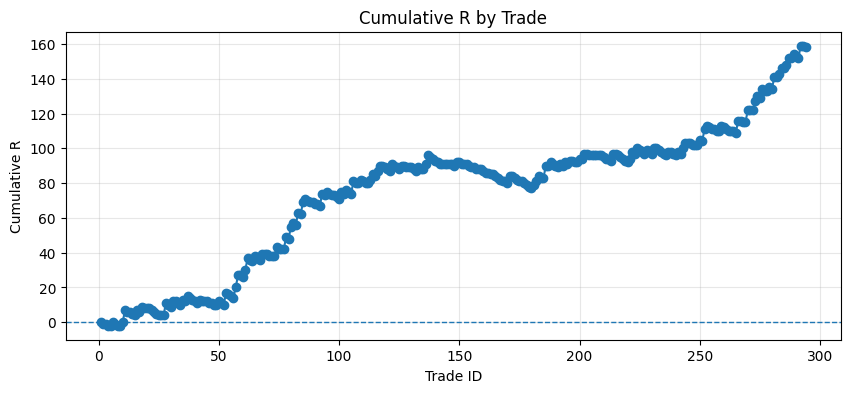

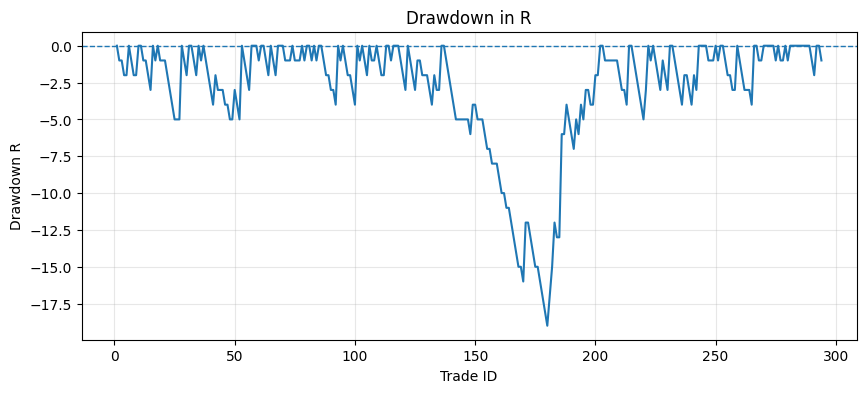

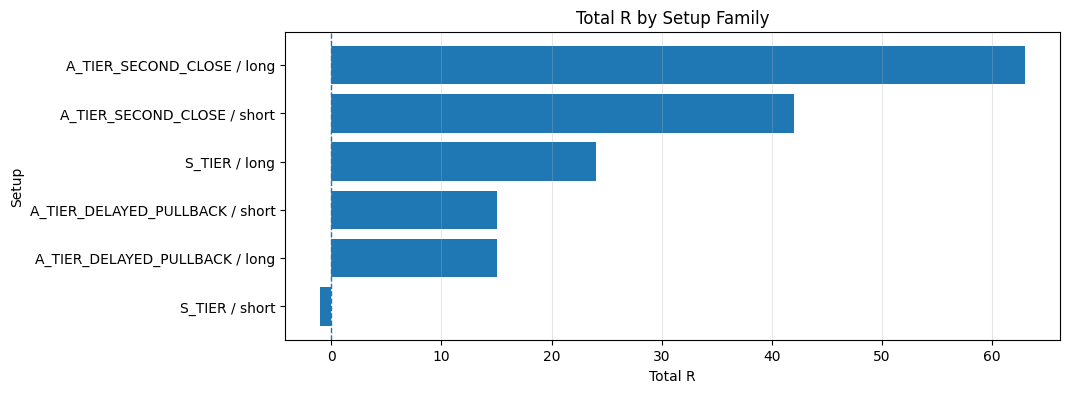

In [154]:
print("Compact visual summary")
print("Trades:", len(trades_df))
print("Total R:", round(float(trades_df["r_multiple"].sum()), 2) if not trades_df.empty else 0.0)

plot_cumulative_r(equity_curve_df)
plot_drawdown_r(equity_curve_df)
plot_setup_r_contribution(setup_results_df)

## Audits and detailed diagnostics

These sections explain why the model did or did not trade.

They are detailed diagnostics, not the first results the user should see.

### Raw signal audit

### Strategy-filter block audit

### Trade attribution report

### Mean-reversion diagnostics

### Protected add-on diagnostics

## Experiment logging

This section saves the current run configuration and headline results.

## Future live runner notes

The future live file should use this notebook's final clean config structure.

Live runner goals:
- one file
- signal-only by default
- optional order placement later
- use same MT5 account/feed/symbol as overlay
- same lookback/session/VWAP/sigma settings as overlay
- clear logging of raw signal, final signal, and skip reason